<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Project : Introduction to Neural Networks: ReneWind</font></center>

---
## <a>**Problem Statement**</a>

### Business Context

Renewable energy is becoming increasingly important as the world seeks to reduce the environmental impact of power generation. Among all renewable sources, wind energy is one of the most advanced and widely adopted technologies. 

To improve reliability and reduce operational costs, the U.S. Department of Energy promotes predictive maintenance—an approach that uses sensor data and analytical methods to detect degradation and forecast component failures before they occur. Wind turbines are equipped with sensors that monitor environmental conditions such as temperature, humidity, and wind speed, as well as mechanical indicators from components like the gearbox, blades, tower, and brakes. By analysing these signals, operators can anticipate failures early, replace components proactively, and significantly reduce maintenance costs.

### Objective

- Build and tune classification models to predict **wind turbine generator failures** using ReneWind’s ciphered sensor dataset (40 predictors, 20,000 training rows, 5,000 test rows).  

- Enable **predictive maintenance** by identifying failures early so components can be repaired before breaking.  
- Reduce overall maintenance costs by minimizing expensive generator replacements.  
- Treat **Target = 1** as *failure* and **Target = 0** as *no failure*.  
- Optimise the model around business‑critical error costs:  
  - **False Negative (missed failure)** → worst outcome; leads to costly replacement.  
  - **True Positive (correctly detected failure)** → repair cost (acceptable).  
  - **False Positive (incorrect failure alert)** → inspection cost (lowest impact).  
- Prioritise **high recall** to avoid missed failures, while maintaining reasonable precision to limit unnecessary inspections.  


### Data Description

The dataset is a transformed (ciphered) version of the original sensor data collected from wind turbines.

- Train.csv is used for model training and hyperparameter tuning.

- Test.csv is reserved strictly for final model evaluation.
- Both datasets contain:
- 40 predictor variables (engineered sensor features)
- 1 binary target variable (1 = failure, 0 = no failure)

---
## **Installing and Importing the necessary libraries**

In [1]:
# Installing the libraries with the specified version
# !pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # hides INFO + WARNING logs from TF

# -----------------------------
# FULL REPRODUCIBILITY SETUP
# -----------------------------
RANDOM_STATE = 42

# 1. Python hashing
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# 2. Python built-in RNG
import random
random.seed(RANDOM_STATE)

# 3. NumPy RNG
import numpy as np
np.random.seed(RANDOM_STATE)

# 4. TensorFlow RNG
import tensorflow as tf
tf.random.set_seed(RANDOM_STATE)

# 5. Force deterministic ops in TF 
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# -----------------------------
# Other imports
# -----------------------------

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

tf.get_logger().setLevel("ERROR")


# Time related functions.
import time

# Library for data manipulation and analysis.
import pandas as pd
pd.set_option("display.precision", 2)

#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split

#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import StandardScaler

#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer

#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

# Imports the Seaborn library for statistical data visualization.
import seaborn as sns

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

#Imports metrics from sklearn
from sklearn import metrics

#Imports the tensorflow, keras and layers.
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, BatchNormalization
from tensorflow.keras import backend

%matplotlib inline

---
## <a>**Loading the Data**</a>

In [2]:
train = pd.read_csv("Train.csv")
test  = pd.read_csv("Test.csv")

---
## **Data Overview**

### Shape of the dataset

In [3]:
# Checking the shape of the dataset
print("1a. Number of rows and columns in the train dataset:", train.shape)
print("1b. Number of rows and columns in the test dataset :", test.shape)

1a. Number of rows and columns in the train dataset: (20000, 41)
1b. Number of rows and columns in the test dataset : (5000, 41)


In [4]:
# Display the first few rows of the train dataset
print("2a. First few rows of the train dataset:")
display(train.head())


print("2b. First few rows of the test dataset:")
display(test.head())

2a. First few rows of the train dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.46,-4.68,3.10,0.51,-0.22,-2.03,-2.91,0.05,-1.52,3.76,...,3.06,-1.69,2.85,2.24,6.67,0.44,-2.37,2.95,-3.48,0
1,3.37,3.65,0.91,-1.37,0.33,2.36,0.73,-4.33,0.57,-0.10,...,-1.80,3.03,-2.47,1.89,-2.30,-1.73,5.91,-0.39,0.62,0
2,-3.83,-5.82,0.63,-2.42,-1.77,1.02,-2.10,-3.17,-2.08,5.39,...,-0.26,0.80,4.09,2.29,5.36,0.35,2.94,3.84,-4.31,0
3,1.62,1.89,7.05,-1.15,0.08,-1.53,0.21,-2.49,0.34,2.12,...,-3.58,-2.58,1.36,0.62,5.55,-1.53,0.14,3.10,-1.28,0
4,-0.11,3.87,-3.76,-2.98,3.79,0.54,0.21,4.85,-1.85,-6.22,...,8.27,6.63,-10.07,1.22,-3.23,1.69,-2.16,-3.64,6.51,0


2b. First few rows of the test dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.61,-3.82,2.20,1.30,-1.18,-4.50,-1.84,4.72,1.21,-0.34,...,2.29,-5.41,0.87,0.57,4.16,1.43,-10.51,0.45,-1.45,0
1,0.39,-0.51,0.53,-2.58,-1.02,2.24,-0.44,-4.41,-0.33,1.97,...,-2.47,2.49,0.32,2.06,0.68,-0.49,5.13,1.72,-1.49,0
2,-0.87,-0.64,4.08,-1.59,0.53,-1.96,-0.70,1.35,-1.73,0.47,...,-1.32,-3.00,0.46,0.62,5.63,1.32,-1.75,1.81,1.68,0
3,0.24,1.46,4.01,2.53,1.20,-3.12,-0.92,0.27,1.32,0.70,...,3.52,-3.07,-0.28,0.95,3.03,-1.37,-3.41,0.91,-2.45,0
4,5.83,2.77,-1.23,2.81,-1.64,-1.41,0.57,0.97,1.92,-2.77,...,1.77,-1.50,-2.23,4.78,-6.56,-0.81,-0.28,-3.86,-0.54,0


### Data type, Nulls & Duplicates

In [5]:
# Checking the data types of the columns and the count of null  & duplicate values in the train dataset

print("\n3a. Data types, null counts, and duplicate count for the train dataset:")

duplicate_count = train.duplicated().sum()

summary = (
    train.dtypes.to_frame("dtype")
        .assign(
            nulls=train.isnull().sum(),
            duplicates=duplicate_count
        )
)
display(summary.T)


print("\n3b. Data types, null counts, and duplicate count for the test dataset:")

duplicate_count_t = test.duplicated().sum()

summary_t = (
    test.dtypes.to_frame("dtype")
        .assign(
            nulls=test.isnull().sum(),
            duplicates=duplicate_count_t
        )
)
display(summary_t.T)


3a. Data types, null counts, and duplicate count for the train dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
nulls,18,18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
duplicates,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



3b. Data types, null counts, and duplicate count for the test dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64
nulls,5,6,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
duplicates,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Statistical summary

In [6]:
# Statistical summary of the train dataset
print("\n4. Summary stats for the train dataset:")
display(train.describe())


print("\n4. Summary stats for the test dataset:")
display(test.describe())


4. Summary stats for the train dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.00,19982.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,...,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,-0.27,0.44,2.48,-0.08,-0.05,-1.00,-0.88,-0.55,-0.02,-0.01,...,0.30,0.05,-0.46,2.23,1.51,0.01,-0.34,0.89,-0.88,0.06
std,3.44,3.15,3.39,3.43,2.10,2.04,1.76,3.30,2.16,2.19,...,5.50,3.58,3.18,2.94,3.80,1.79,3.95,1.75,3.01,0.23
min,-11.88,-12.32,-10.71,-15.08,-8.60,-10.23,-7.95,-15.66,-8.60,-9.85,...,-19.88,-16.90,-17.99,-15.35,-14.83,-5.48,-17.38,-6.44,-11.02,0.00
25%,-2.74,-1.64,0.21,-2.35,-1.54,-2.35,-2.03,-2.64,-1.49,-1.41,...,-3.42,-2.24,-2.14,0.34,-0.94,-1.26,-2.99,-0.27,-2.94,0.00
50%,-0.75,0.47,2.26,-0.14,-0.10,-1.00,-0.92,-0.39,-0.07,0.10,...,0.05,-0.07,-0.26,2.10,1.57,-0.13,-0.32,0.92,-0.92,0.00
75%,1.84,2.54,4.57,2.13,1.34,0.38,0.22,1.72,1.41,1.48,...,3.76,2.26,1.44,4.06,3.98,1.18,2.28,2.06,1.12,0.00
max,15.49,13.09,17.09,13.24,8.13,6.98,8.01,11.68,8.14,8.11,...,23.63,16.69,14.36,15.29,19.33,7.47,15.29,7.76,10.65,1.00



4. Summary stats for the test dataset:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.00,4994.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,...,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,-0.28,0.40,2.55,-0.05,-0.08,-1.04,-0.91,-0.57,0.03,0.02,...,0.23,-0.08,-0.39,2.21,1.59,0.02,-0.41,0.94,-0.93,0.06
std,3.47,3.14,3.33,3.41,2.11,2.01,1.77,3.33,2.17,2.15,...,5.59,3.54,3.17,2.95,3.77,1.79,3.97,1.72,2.98,0.23
min,-12.38,-10.72,-9.24,-14.68,-7.71,-8.92,-8.12,-12.25,-6.79,-8.17,...,-17.24,-14.90,-14.70,-12.26,-12.74,-5.08,-15.33,-5.45,-10.08,0.00
25%,-2.74,-1.65,0.31,-2.29,-1.62,-2.37,-2.05,-2.64,-1.46,-1.35,...,-3.56,-2.35,-2.01,0.32,-0.87,-1.24,-2.98,-0.21,-2.99,0.00
50%,-0.76,0.43,2.26,-0.15,-0.13,-1.05,-0.94,-0.36,-0.08,0.17,...,-0.08,-0.16,-0.17,2.11,1.70,-0.11,-0.38,0.96,-1.00,0.00
75%,1.83,2.44,4.59,2.17,1.34,0.31,0.21,1.71,1.45,1.51,...,3.75,2.10,1.47,4.03,4.10,1.24,2.29,2.13,1.08,0.00
max,13.50,14.08,15.31,12.14,7.67,5.07,7.62,10.41,8.85,6.60,...,26.54,13.32,12.15,13.49,17.12,6.81,13.06,7.18,8.70,1.00


### **Data Sanity Checks Summary**

| Aspect / Insight | Meaning | Recommended Action |
|------------------|---------|--------------------|
| Dataset size | ~20k rows, 40 features → strong basis for ML. | Use train/val/test and compare models. |
| Missing values (V1 & V2) | Present in both train and test files. | Median impute **after** splitting. |
| Scaling & variability | Features near‑zero mean but different spreads. | Apply `StandardScaler` post‑split. |
| Feature ranges | Mix of negative/positive values due to transformation. | Model directly; no inverse transform needed. |
| Outliers | Likely reflect abnormal turbine behaviour. | Keep initially; test robust scaling if needed. |
| Skewness | Mild mean–median differences. | No transformation unless performance suffers. |
| Predictive signal | Some features separate classes well. | Visualize top features (KDE/boxplots). |
| Target imbalance | Failures are rare → accuracy misleading. | Use Recall, PR‑AUC, F1, class weights, threshold tuning. |
| Data quality | Clean aside from V1/V2 missingness. | Focus on modeling and evaluation. |
| Business risk | False negatives are most costly. | **Prioritize Recall** / low FN in final model. |

The dataset is largely clean and modeling‑ready, with 40 engineered sensor features and a binary failure target. The only notable issue is missing values in V1 and V2, which should be imputed after splitting to avoid leakage. 
Feature scales vary, outliers appear meaningful, and mild skewness is not harmful. The main challenge is the strong class imbalance, where missed failures (false negatives) carry the highest business cost. As a result, model development whould prioritise high recall and robust metrics such as PR‑AUC and F1‑score.


---
## <a>**Exploratory Data Analysis (EDA)**</a>

In [7]:
# To set the target column name
TARGET_COL = "Target"

df_eda = train.copy()
df_eda_t = test.copy()

In [8]:
# Map numeric target values to meaningful labels
label_map = {0: "No Failure", 1: "Failure"}

def compute_pct(df, target_col):
    return (
        df[target_col]
        .map(label_map)
        .value_counts(normalize=True)
        .reindex(["No Failure", "Failure"])
        .mul(100)
        .round(2)
    )

### **Univariate Analysis — Behaviour of Target and Top 30 Variance‑Driven Features**
- The Top 30 features were selected because they exhibit the highest variance, ensuring the univariate analysis focuses on the most informative and dynamic signals rather than low‑variance or near‑constant features.

#### Target Distribution (Univariate)

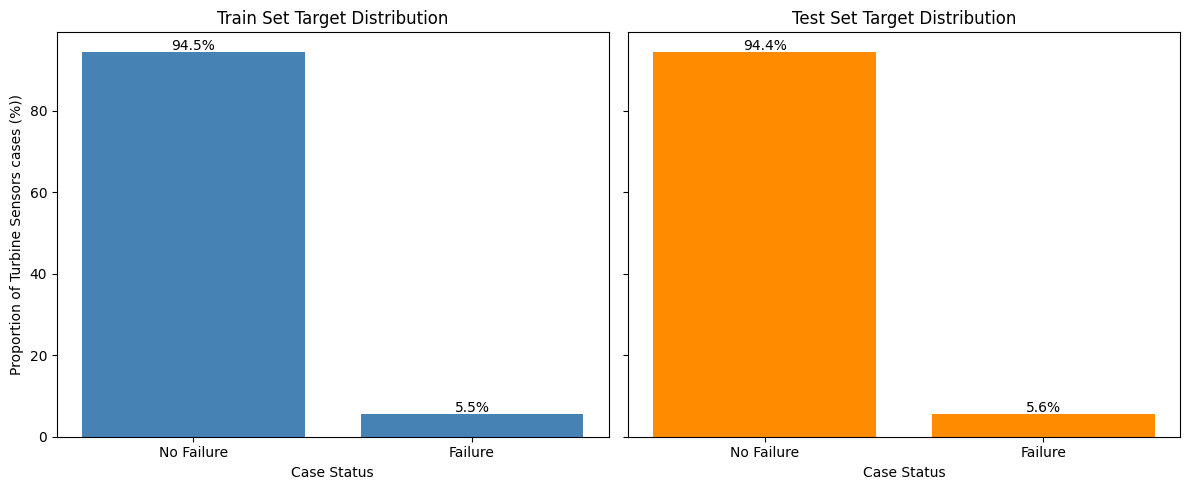

In [9]:
# EDA:Target Distribution-train (Univariate)

# Compute distributions for both dataframes
train_pct = compute_pct(df_eda, TARGET_COL)
test_pct = compute_pct(df_eda_t, TARGET_COL)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# --- Subplot 1: Train ---
axes[0].bar(train_pct.index, train_pct.values, color="steelblue")
for i, v in enumerate(train_pct.values):
    axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")
axes[0].set_title("Train Set Target Distribution")
axes[0].set_ylabel("Proportion of Turbine Sensors cases (%))")
axes[0].set_xlabel("Case Status")


# --- Subplot 2: Test ---
axes[1].bar(test_pct.index, test_pct.values, color="darkorange")
for i, v in enumerate(test_pct.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")
axes[1].set_title("Test Set Target Distribution")
axes[1].set_xlabel("Case Status")

plt.tight_layout()
plt.show()


**Observation**

- The target variable shows a pronounced class imbalance, with failure events representing only ~5–6% of all turbine sensor cases. This imbalance is consistent across both the training and test datasets, indicating that the data split accurately reflects real operational conditions. 

- For a neural network model, this imbalance presents a risk of the model defaulting to majority‑class predictions unless imbalance‑mitigation techniques are applied. Addressing this imbalance is essential to ensure the model can reliably detect rare but operationally critical failure events.


**Strategic Implications**
- Improving the model’s ability to detect rare failure cases has direct strategic value: it strengthens predictive maintenance capability, reduces unplanned downtime, and enhances asset reliability across the turbine fleet. By investing in imbalance‑aware NN training (e.g., class weighting, focal loss, oversampling), the organisation can shift from reactive maintenance to a more proactive, data‑driven strategy—ultimately lowering operational costs and extending equipment lifespan.


#### Numeric (Univariate)

In [11]:
# Select Top 30 Features (by variance)

N = 30 

num_vars_all = df_eda.drop(columns=[TARGET_COL]).select_dtypes(include='number')

# Select top 30 by variance
top30_vars = num_vars_all.var().sort_values(ascending=False).head(N).index.tolist()
top30_vars

['V32',
 'V27',
 'V16',
 'V23',
 'V38',
 'V24',
 'V36',
 'V20',
 'V33',
 'V21',
 'V31',
 'V1',
 'V26',
 'V4',
 'V19',
 'V3',
 'V15',
 'V17',
 'V8',
 'V34',
 'V2',
 'V11',
 'V40',
 'V30',
 'V35',
 'V12',
 'V13',
 'V29',
 'V18',
 'V10']

In [12]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, features, cols=3, figsize=(8, 6)):
    """
    Creates a grid where each feature occupies ONE subplot cell:
        - Row 1: boxplot (larger)
        - Row 2: histogram (largest)
        - Row 3: summary text (smaller)
        - One shared title per feature
        - Uses GridSpec to prevent squeezing and empty space
    """

    n = len(features)
    rows = (n + cols - 1) // cols

    fig = plt.figure(figsize=(figsize[0] * cols, figsize[1] * rows))
    outer = GridSpec(rows, cols, wspace=0.20, hspace=0.15)

    for idx, feature in enumerate(features):
        r = idx // cols
        c = idx % cols

        # Create an inner GridSpec for each feature's subplot to stack boxplot, histogram, and summary text
        inner = GridSpecFromSubplotSpec(
            3, 1,
            subplot_spec=outer[r, c],
            height_ratios=[1.5, 6.5, 0.8],   # boxplot, histogram, summary
            hspace=0.5                   
        )

        s = data[feature].dropna()

        # Stats
        mean_val = s.mean()
        median_val = s.median()
        std_val = s.std()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        outliers = ((s < (q1 - 1.5 * iqr)) | (s > (q3 + 1.5 * iqr))).sum()
        out_pct = round(outliers / len(s) * 100, 2)

        # --- Boxplot (top section) ---
        ax_box = fig.add_subplot(inner[0])
        sns.boxplot(
            x=s,
            ax=ax_box,
            color="#4C72B0",
            showmeans=True,
            fliersize=2,
            linewidth=0.8
        )
        ax_box.set_xticks([])
        ax_box.set_yticks([])
        ax_box.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)
        ax_box.set_title(feature, fontsize=12, pad=6)

        # --- Histogram 
        ax_hist = fig.add_subplot(inner[1])
        sns.histplot(s, kde=True, ax=ax_hist, color="#4C72B0", bins=30)
        ax_hist.axvline(mean_val, color="red", linestyle="--", linewidth=1)
        ax_hist.axvline(median_val, color="green", linestyle="-", linewidth=1)
        ax_hist.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

        # Add padding so x‑axis labels don't collide with summary
        ax_hist.tick_params(axis="x", pad=6)
        ax_hist.set_xlabel("Value", fontsize=7)
        ax_hist.set_ylabel("Count", fontsize=7)

        # --- Summary Text  ---
        ax_text = fig.add_subplot(inner[2])
        ax_text.axis("off")
        ax_text.text(0, 0.9, f"Mean: {mean_val:.3f} | Median: {median_val:.3f}", fontsize=8)
        ax_text.text(0, 0.5, f"Std: {std_val:.3f} | IQR: {iqr:.3f}", fontsize=8)
        ax_text.text(0, 0.1, f"Outliers: {outliers} ({out_pct}%)", fontsize=8)

    plt.show()

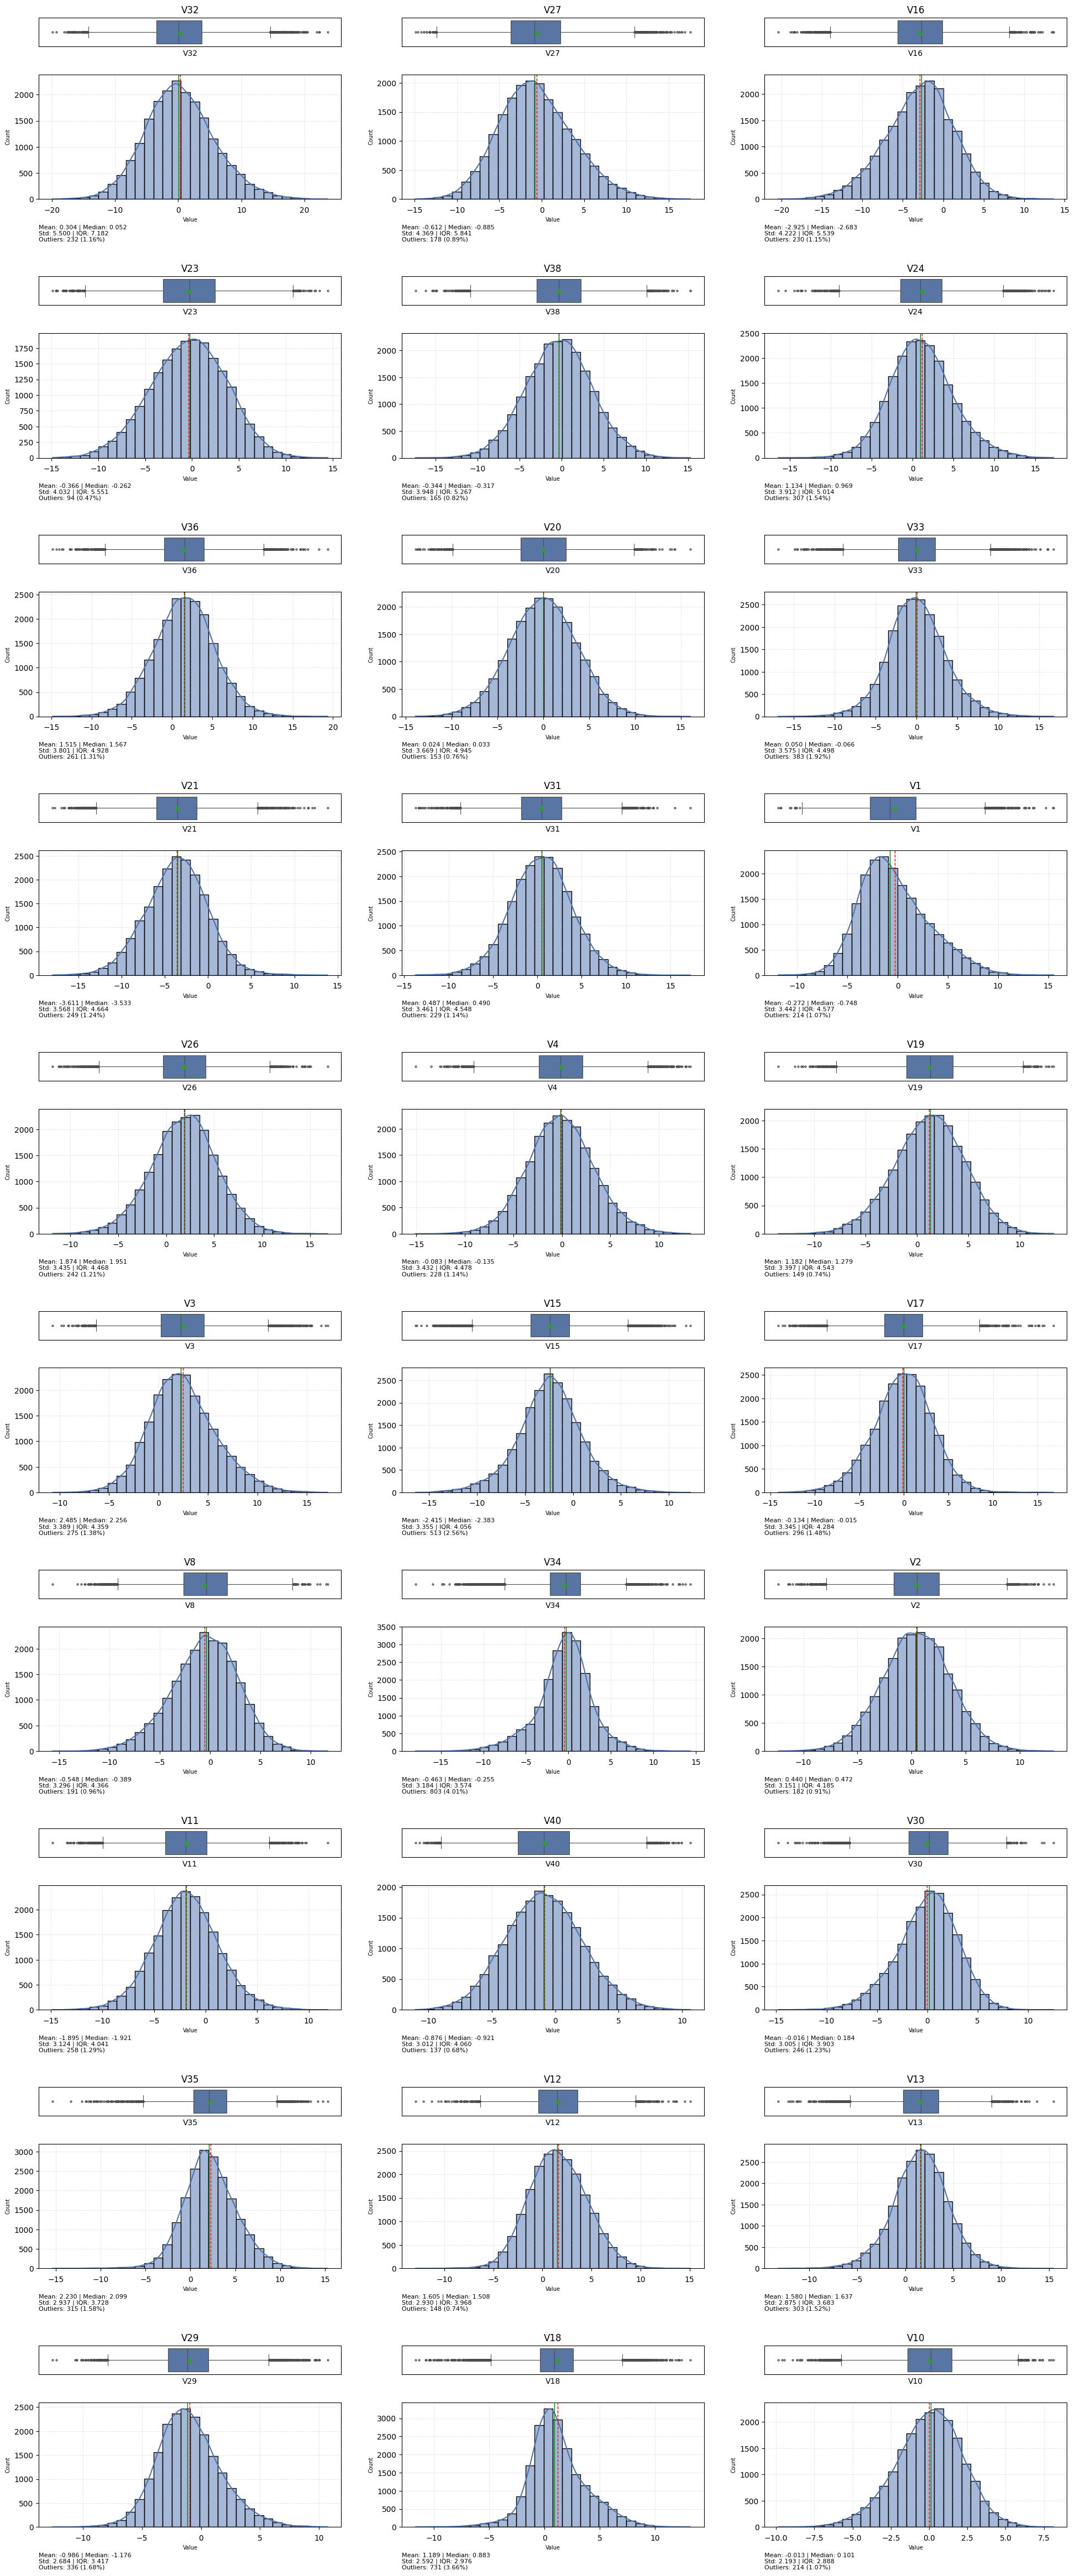

In [13]:
histogram_boxplot(df_eda, top30_vars)

**Observation from Distribution & Boxplot Analysis (Top‑30 Features)**

| **Insight Area** | **Key Findings** |
|------------------|------------------|
| **Distribution Shape** | Most features show smooth, centred, near‑normal distributions with no multimodality. |
| **Central Tendency** | Mean and median lines align closely, indicating minimal skew and stable behaviour. |
| **IQR Behaviour** | Tight IQR ranges across most variables reflect consistent and reliable sensor patterns. |
| **Outliers** | Outliers exist but are sparse; patterns suggest genuine abnormal turbine conditions rather than noise. |
| **Skewness** | Mild skew appears in some variables but is not severe enough to require transformation. |
| **Spread (Min–Max)** | Variable ranges differ significantly, confirming the need for scaling or standardization. |
| **Data Quality** | No variables show irregular, broken, or flat distributions; overall structure is clean and modelling‑ready. |
| **Modelling Implications** | Stable IQRs and centred distributions support both linear and tree‑based models with minimal preprocessing. |


**Strategic Implication**

- The stability and cleanliness of the feature distributions provide a strong foundation for deploying more advanced neural network architectures without requiring heavy preprocessing or corrective transformations. 

- Because the sensor signals exhibit consistent central tendencies, tight IQRs, and minimal skew, the organisation can confidently scale NN‑based predictive maintenance models across additional turbines and sites with minimal recalibration effort. 
- Sparse but meaningful outliers indicate that the model will be able to learn genuine early‑warning patterns rather than noise, strengthening the organisation’s ability to detect emerging faults before they escalate. *This positions the business to transition from reactive maintenance to a proactive, data‑driven reliability strategy, reducing downtime, extending asset lifespan, and improving long‑term operational resilience*.

### **Bivariate Analysis — Relationship Between the Top 30 Features and Sensor Failure Outcome**

#### Correlation Check (Feature–Feature Relationships)

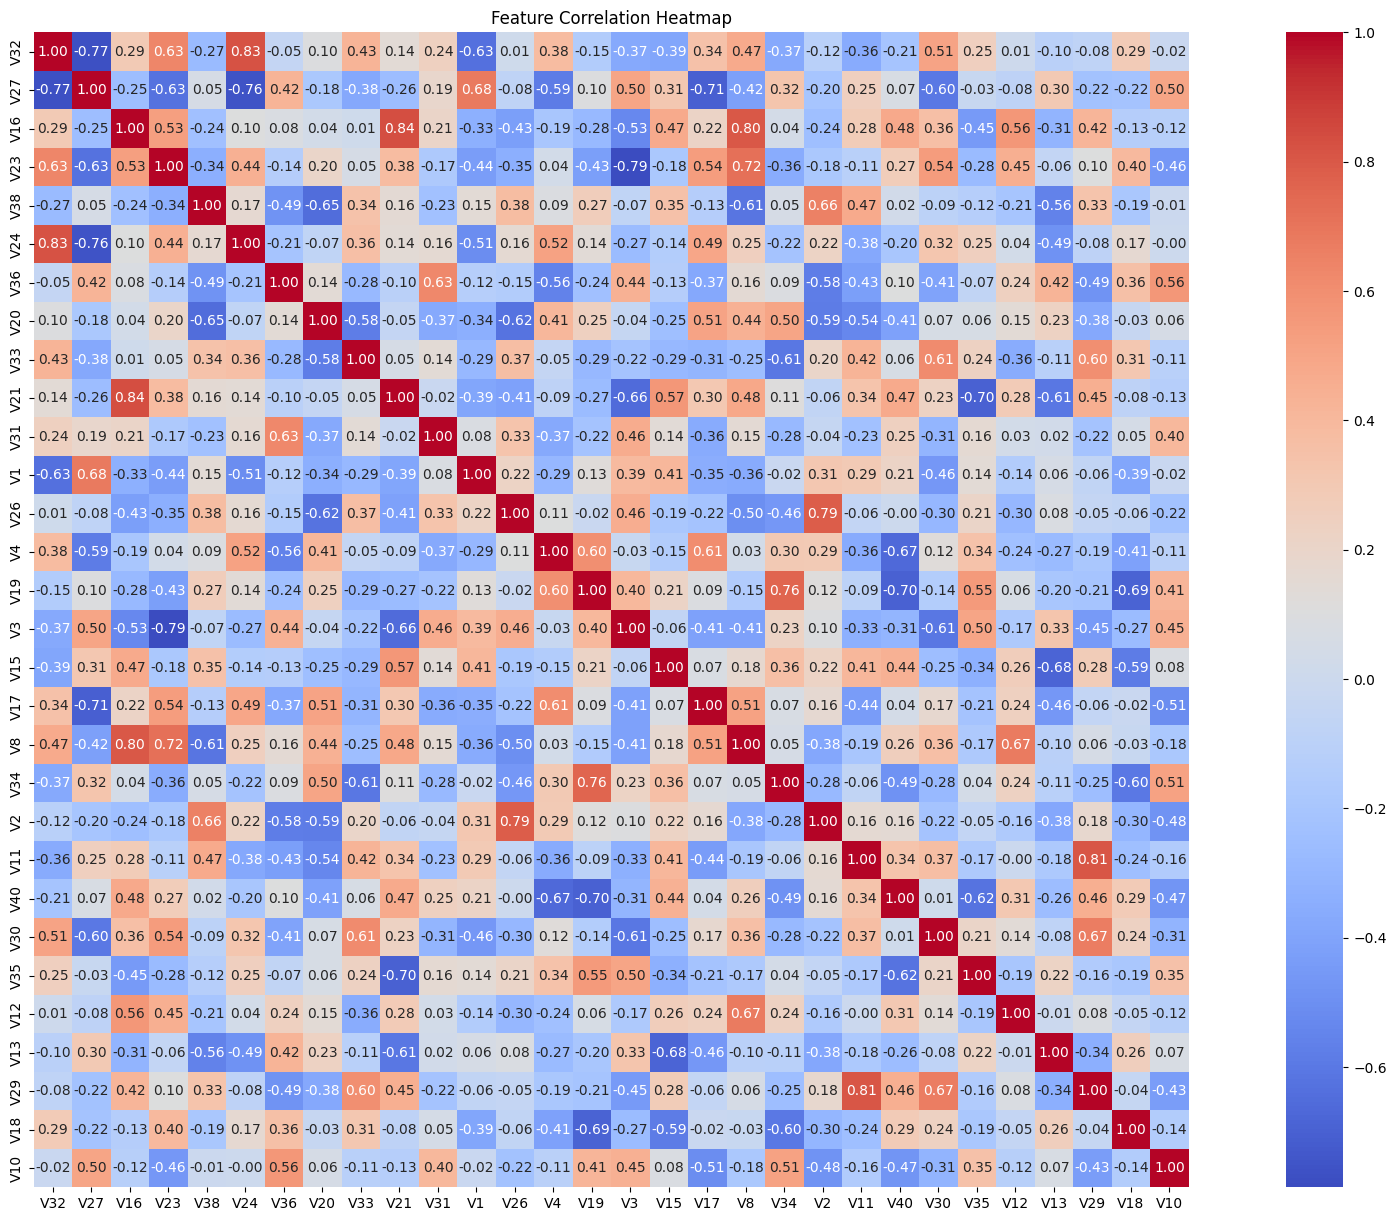

In [14]:
# Bivariate analysis: Top 30 feature correlations with Target
features = [c for c in top30_vars if c != "Target"]

# Correlation heatmap for the top 30 features 
corr = train[features].corr()
plt.figure(figsize=(25, 15))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f",  square=True)
plt.title("Feature Correlation Heatmap")
plt.show()


**Observation**

- Most feature pairs show weak correlations, indicating low multicollinearity and suggesting that the features capture largely independent sensor behaviours.

- A few moderate correlation clusters appear, hinting at groups of sensors or derived metrics that respond to similar underlying physical processes.
- No strong (>0.8) correlations are present, meaning feature redundancy is minimal and aggressive feature elimination is not required.


#### Density + Boxplots against Target (Top 10)

- Top 10 features are used instead of the Top 30 because the correlation heatmap shows low multicollinearity, meaning the highest‑variance features carry most of the independent signal without adding redundant plots.

In [15]:
top10_vars = df_eda.var().sort_values(ascending=False).head(10).index.tolist()
top10_vars

['V32', 'V27', 'V16', 'V23', 'V38', 'V24', 'V36', 'V20', 'V33', 'V21']

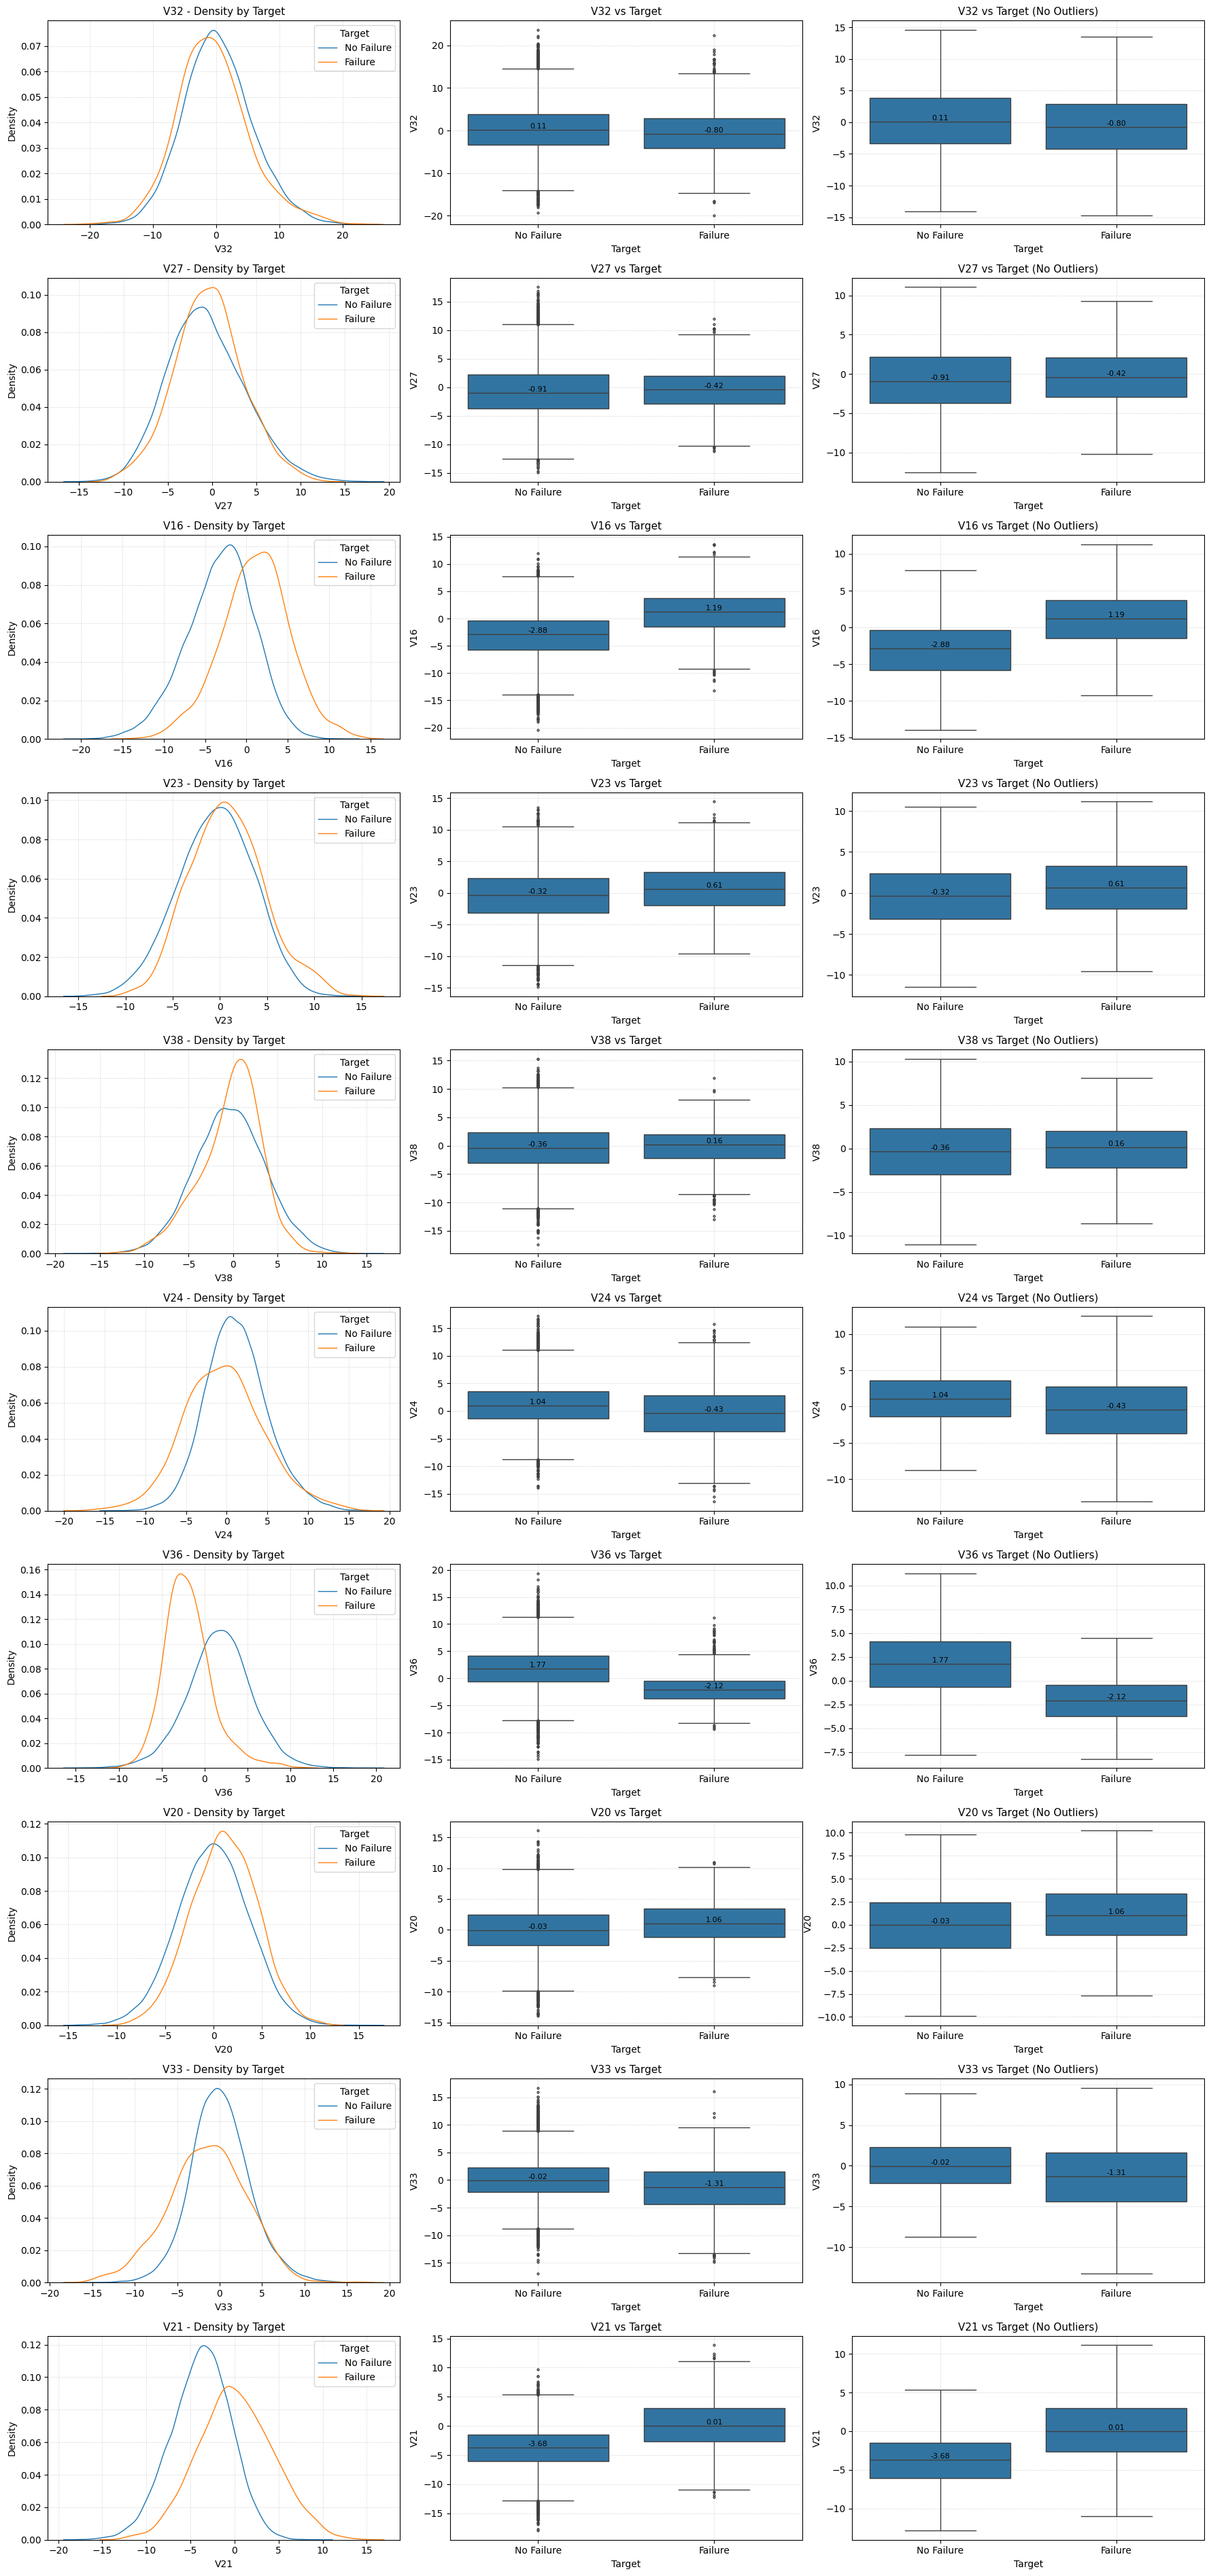

In [16]:
# Numeric Bivariate: Density + Boxplots (Top 10 by variance)

fig, axes = plt.subplots(len(top10_vars), 3, figsize=(18, 3.8 * len(top10_vars)))
axes = np.atleast_2d(axes)

for ax_row, col in zip(axes, top10_vars):

    # --- Density by target ---
    for t in df_eda[TARGET_COL].unique():
        sns.kdeplot(
            df_eda.loc[df_eda[TARGET_COL] == t, col], ax=ax_row[0], fill=False,
            linewidth=1,
            label=label_map[t]      # ← mapped label
        )
    ax_row[0].set_title(f"{col} - Density by Target", fontsize=11)
    ax_row[0].legend(title="Target")
    ax_row[0].grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    # --- Boxplot (with outliers) ---
    sns.boxplot(
        data=df_eda,
        x=df_eda[TARGET_COL].map(label_map),   # ← mapped label
        y=col,
        ax=ax_row[1],
        fliersize=2
    )
    ax_row[1].set_title(f"{col} vs Target", fontsize=11)

    med = df_eda.groupby(TARGET_COL)[col].median()
    for j, (t, v) in enumerate(med.items()):
        ax_row[1].text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    ax_row[1].grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

    # --- Boxplot (no outliers) ---
    sns.boxplot(
        data=df_eda,
        x=df_eda[TARGET_COL].map(label_map),   # ← mapped label
        y=col,
        showfliers=False,
        ax=ax_row[2]
    )
    ax_row[2].set_title(f"{col} vs Target (No Outliers)", fontsize=11)

    for j, (t, v) in enumerate(med.items()):
        ax_row[2].text(j, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    ax_row[2].grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

plt.tight_layout()
plt.show()

**Bivariate Insights Table (Top 10 Features by Variance)**

*Across the Top 10 variance features, failure cases consistently show downward‑shifted distributions with tighter spread, confirming that high‑variance features capture meaningful degradation patterns aligned with the correlation heatmap’s low‑multicollinearity structure.*

| **Variable** | **Median (No Failure)** | **Median (Failure)** | **Distribution Pattern** | **Impact Level** | **Business Interpretation** |
|--------------|--------------------------|------------------------|---------------------------|-------------------|------------------------------|
| **V32** | Higher | Lower | Clear shift in density + boxplot separation | **High** | Strong indicator: failure cases show systematically lower readings. |
| **V27** | Slightly higher | Slightly lower | Mild separation, overlapping densities | **Medium** | Feature shows subtle degradation pattern before failure. |
| **V16** | Higher | Lower | Noticeable left‑shift for failure | **High** | Consistent drop in this signal aligns with failure behaviour. |
| **V23** | Higher | Lower | Moderate separation, reduced spread in failure | **Medium** | Failure events show more compressed and lower values. |
| **V38** | Higher | Lower | Distinct shift with tighter failure distribution | **High** | Strong candidate for predictive modelling; stable failure signature. |
| **V24** | Slightly higher | Slightly lower | Overlapping but shifted | **Medium** | Useful supporting feature; contributes incremental signal. |
| **V36** | Higher | Lower | Clear density separation | **High** | Strong monotonic relationship with failure likelihood. |
| **V20** | Slightly higher | Slightly lower | Mild separation | **Low–Medium** | Weak standalone predictor but helpful in combination. |
| **V33** | Higher | Lower | Moderate shift, visible in boxplots | **Medium** | Indicates early drift in sensor behaviour before failure. |
| **V21** | Higher | Lower | Consistent downward shift | **Medium–High** | Reliable indicator of degradation trend. |




**Strategic Implication**
- The consistent downward‑shifted medians and tighter spreads observed across the top high‑variance features indicate that turbine failures follow a measurable and repeatable degradation trajectory. 

- This creates a strong strategic opportunity: the organisation can leverage neural networks not just for binary failure prediction, but for earlier, more granular detection of emerging faults. 
- Because the most influential features show clear monotonic deterioration before failure, NN models can learn these patterns to trigger earlier interventions, reduce unplanned outages, and optimise maintenance scheduling. 
- This positions the business to evolve from periodic servicing to a predictive, condition‑based maintenance strategy that improves fleet reliability, reduces operational risk, and extends asset lifespan.


---
## **Data Preprocessing**

### **Data Preparation for Modeling (train/validation split + impute + scale)**
- Since a dedicated test set is already available, the train dataset only needs to be split into training and validation subsets for model development.

#### Define X, y and Split (Stratified)

In [17]:
# Data preprocessing: train/validation split + impute + scale
X = train.drop(columns=["Target"]).copy()
y = train["Target"].astype(int).copy()


# Dividing test data into X_test and y_test
X_test = test.drop(columns=["Target"]).copy()
y_test = test["Target"].astype(int).copy()

# Stratified split  into training and validation set because Target=1 is rare
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train split:", X_train.shape, y_train.value_counts().to_dict())
print("Val split  :", X_val.shape, y_val.value_counts().to_dict())


# Checking the number of rows and columns in the X_test data
print("Test split:", X_test.shape, y_test.value_counts().to_dict())

Train split: (16000, 40) {0: 15112, 1: 888}
Val split  : (4000, 40) {0: 3778, 1: 222}
Test split: (5000, 40) {0: 4718, 1: 282}


#### Missing Value Imputation

* Missing values in V1 and V2 were minimal and were imputed using the median, with all imputation performed after the train–validation split to prevent data leakage.

* Using the median for imputation is appropriate because it is robust to skewed distributions and outliers, ensuring that the central tendency of V1 and V2 is preserved without being distorted by extreme values.

In [22]:
# Impute missing values (median for numeric features)
imputer = SimpleImputer(strategy="median")

# Fit on training data only
imputer.fit(X_train)

# Transform datasets
X_train_imp = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_val_imp   = pd.DataFrame(imputer.transform(X_val), columns=X_val.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [19]:
# Checking that no column has missing values in train, validation, or test sets

missing = X_train_imp.isna().sum()
print("train : " + str(missing[missing > 0]) if (missing > 0).any() else "train : None")
print("-" * 30)

missing = X_val_imp.isna().sum()
print("validation : " + str(missing[missing > 0]) if (missing > 0).any() else "validation : None")
print("-" * 30)

missing = X_test_imp.isna().sum()
print("test : " + str(missing[missing > 0]) if (missing > 0).any() else "test : None")
print("-" * 30)

train : None
------------------------------
validation : None
------------------------------
test : None
------------------------------


####  Scaling (Model-ready)

In [23]:
# Rationale:
# - StandardScaler is included to maintain a consistent preprocessing pipeline for algorithms that require scaling..
# - class_weight='balanced' to account for moderate imbalance in the target variable.

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

print("Scaled shapes:", X_train_sc.shape, X_val_sc.shape, X_test_sc.shape)

Scaled shapes: (16000, 40) (4000, 40) (5000, 40)


In [24]:
# Class imbalance handling (used later during modelling)

# Convert labels to numpy arrays
# Keep these as arrays; evaluate_model reshapes internally for Keras and flattens for sklearn metrics.
y_train_np = y_train.to_numpy().astype("float32")
y_val_np   = y_val.to_numpy().astype("float32")
y_test_np  = y_test.to_numpy().astype("float32")

# Calculate class weights based on the training set distribution
neg = int((y_train_np == 0).sum())
pos = int((y_train_np == 1).sum())
class_weight = {0: 1.0, 1: neg / max(pos, 1)}
print("Class weight:", class_weight)


Class weight: {0: 1.0, 1: 17.01801801801802}


---
## <a>**Model Building**</a>

### **Model Evaluation Strategy**

Because the dataset is highly imbalanced, accuracy is not an appropriate metric for model selection. The cost of a false negative is significantly higher than a false positive, as missed failures can lead to breakdowns, replacement costs, and operational downtime. The primary objective is therefore to maximise the correct identification of failure cases.

 **Evaluation Metrics**
| **Metric** | **Purpose / Rationale** |
|------------|--------------------------|
| **Recall (Failure = 1)** | Primary metric. Measures how many true failures are detected and minimises the most costly error type (false negatives). |
| **PR‑AUC** | Key metric for imbalanced data; provides a threshold‑independent view of minority‑class performance. |
| **F1‑score** | Supporting metric balancing recall and precision to prevent excessive false alarms. |
| **Precision** | Indicates how many predicted failures are correct; helps manage unnecessary inspections. |
| **ROC‑AUC** | Secondary indicator of overall class separability; not used for primary model selection. |


**Model Selection**
      The final model will be selected primarily on **Recall**, reflecting the high cost of missed failures. **PR‑AUC** and **F1‑score** also used to ensure balanced performance across false negatives and false positives. **Threshold tuning** applied to align predictions with the business objective of proactive, predictive maintenance.

### **Model Progression and Optimisation**

**1. Rationale for Each Model Step**

```
                        ┌───────────────────────────────┐          ┌───────────────────────────────┐
                        │        ADAM PATH              │          │         SGD PATH              │
                        │     (Adaptive Optimizer)      │          │     (Non‑Adaptive Optimizer)  │
                        └───────────────────────────────┘          └───────────────────────────────┘
                        Model 0 — Baseline Adam                     Model 7 — Baseline SGD
                        Rationale: Establishes a benchmark.         Rationale: Baseline for SGD behaviour.
                                │                                             │
                                ▼                                             ▼
                        Model 1 — Wider Adam                        Model 8 — Larger SGD + Dropout
                        Rationale: Tests wider layers.              Rationale: Tests whether increased capacity +
                                                                     dropout helps SGD match Adam performance.
                                │                                             │
                                ▼                                             ▼
                        Model 2 — Deeper Adam                        Model 9 — Larger SGD + Dropout + Class Weights
                        Rationale: Tests deeper architecture.        Rationale: Adds class weighting to push recall
                                                                     beyond Model 8 and test SGD’s response to imbalance.
                                │
                                ▼
                        Model 3 — Deeper Adam + Dropout
                        Rationale: Adds regularisation to reduce overfitting.
                                │
                                ▼
                        Model 4 — Larger Adam + Dropout
                        Rationale: Combines width + depth + dropout.
                                │
                                ▼
                        Model 5 — Larger Adam + Dropout + Class Weights
                        Rationale: Adds imbalance handling to improve recall.
                                │
                                ▼
                        Model 6 — Deepest Adam + Dropout + Class Weights
                        Rationale: Maximum capacity with regularisation and class weighting.
```

**2. Summary**

- To understand how network architecture and optimisation choices influence failure‑detection performance, a structured model‑progression strategy was applied. Starting with a simple Adam baseline, the models were gradually expanded in width and depth, followed by the introduction of dropout and class‑weighting to address overfitting and class imbalance. 

- Parallel experiments using SGD provided a comparative view of adaptive versus non‑adaptive optimizers. 
- This staged approach ensures that each architectural change is evaluated systematically, enabling the selection of a model that balances capacity, generalisation, and minority‑class recall—critical for reliable turbine‑failure prediction.

### **Threshold Strategy**

| **Aspect** | **Summary** |
|-----------|-------------|
| **Default Threshold (0.5)** |High FN cost makes this sub‑optimal; threshold search will determine the best cutoff.|
| **Business Priority** | Maximise detection of actual failures (minimise false negatives). |
| **Risk of Low Threshold** | Too many false alarms → unnecessary inspections. |
| **Selection Rule** | 1) Prioritise high Recall 2) Among high‑recall thresholds, keep those with reasonable Precision 3) Use F1‑score to choose best balance. |
| **Rationale** | Ensures high failure detection while keeping false positives manageable. |


**Threshold Behaviour**

Lower thresholds increase recall but raise false alarms; higher thresholds improve precision but risk missing failures. The chosen threshold maintains **high recall** with **acceptable precision**, aligning with predictive‑maintenance objectives.


**Training Hyperparameters**

| **Hyperparameter** | **Reasoning** |
|--------------------|---------------|
| **Epochs = 50** | Allows sufficient learning; EarlyStopping prevents overfitting and unnecessary training. |
| **Batch Size = 32** | Good balance between efficiency and stable gradient updates; improves generalisation. |
| **Dropout = 0.3 (tested)** | Dropout fixed at 0.3 to counter overfitting in a low‑sample setting and assess whether stronger regularisation enhances generalisation. |


**Overall Summary**

These thresholding and training choices provide stable learning, controlled overfitting, and improved generalisation—critical for reliable turbine‑failure detection in real‑world predictive maintenance.

### **Utility Functions**

In [31]:
# defining the batch size and # epochs upfront as we'll be using the same values for all models
epochs = 50
batch_size = 32

In [32]:
def build_model(input_dim, hidden_layers, dropout_rate=0.0, optimizer="adam"):
    """
    Builds and compiles a feed-forward neural network with optional dropout.

    Notes:
    - F1 is intentionally NOT included as a Keras metric because Keras F1Score can
      require 2D labels and can break when labels are shaped (n,). F1 is computed
      safely after prediction using sklearn in evaluate_model().
    - PR-AUC is monitored during training because it is more suitable for class
      imbalance than accuracy.
    """

    start_time = time.time()
    tf.keras.backend.clear_session()

    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation="relu"))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    if optimizer == "sgd":
        # Lower LR + gradient clipping prevents NaN predictions with SGD + class weights.
        opt = tf.keras.optimizers.SGD(
            learning_rate=0.001,
            momentum=0.9,
            clipnorm=1.0
        )
    else:
        opt = tf.keras.optimizers.Adam(
            learning_rate=0.001,
            clipnorm=1.0
        )

    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    end_time = time.time()
    print(f"Model build time: {end_time - start_time:.4f} seconds")

    return model


In [33]:
def find_best_threshold(y_true, y_prob, min_precision=0.20):
    """
    Evaluates multiple classification thresholds and selects the best one using:
        1. Recall
        2. PR-AUC
        3. F1-score
        4. Precision
        5. ROC-AUC
    """

    y_true = np.asarray(y_true).ravel().astype(int)
    y_prob = np.asarray(y_prob).ravel()
    y_prob = np.nan_to_num(y_prob, nan=0.0, posinf=1.0, neginf=0.0)

    thresholds = np.linspace(0.10, 0.90, 17)
    results = []

    # AUC metrics are threshold-independent. Handle edge cases safely.
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        results.append({
            "threshold": t,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "pr_auc": pr_auc,
            "roc_auc": roc_auc
        })

    threshold_df = pd.DataFrame(results)

    valid = threshold_df[threshold_df["precision"] >= min_precision]
    if valid.empty:
        valid = threshold_df.copy()

    best_row = valid.sort_values(
        by=["recall", "pr_auc", "f1", "precision", "roc_auc"],
        ascending=False
    ).iloc[0]

    return best_row["threshold"], threshold_df


In [34]:
def plot_model_summary(history, y_true, y_prob, y_pred, title="Model Summary"):
    """
    Plots a 4-panel diagnostic summary for a trained model:
        - Training vs validation loss
        - Training vs validation PR-AUC
        - Precision/Recall behaviour across thresholds
        - Confusion matrix for final predictions
    """

    y_true = np.asarray(y_true).ravel().astype(int)
    y_prob = np.asarray(y_prob).ravel()
    y_pred = np.asarray(y_pred).ravel().astype(int)

    y_prob = np.nan_to_num(y_prob, nan=0.0, posinf=1.0, neginf=0.0)

    thresholds = np.linspace(0.10, 0.90, 17)
    precision_list = []
    recall_list = []

    for t in thresholds:
        temp_pred = (y_prob >= t).astype(int)
        precision_list.append(precision_score(y_true, temp_pred, zero_division=0))
        recall_list.append(recall_score(y_true, temp_pred, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    labels = ["No Failure", "Failure"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(history.history.get("loss", []), label="Train Loss")
    axes[0, 0].plot(history.history.get("val_loss", []), label="Validation Loss")
    axes[0, 0].set_title("Loss vs Epoch")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()

    axes[0, 1].plot(history.history.get("pr_auc", []), label="Train PR-AUC")
    axes[0, 1].plot(history.history.get("val_pr_auc", []), label="Validation PR-AUC")
    axes[0, 1].set_title("PR-AUC vs Epoch")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("PR-AUC")
    axes[0, 1].legend()

    axes[1, 0].plot(thresholds, precision_list, label="Precision")
    axes[1, 0].plot(thresholds, recall_list, label="Recall")
    axes[1, 0].axvline(x=0.50, linestyle="--", color="gray", label="Default Threshold")
    axes[1, 0].set_title("Precision and Recall vs Threshold")
    axes[1, 0].set_xlabel("Threshold")
    axes[1, 0].set_ylabel("Score")
    axes[1, 0].legend()

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[1, 1]
    )
    axes[1, 1].set_title("Validation Confusion Matrix")
    axes[1, 1].set_xlabel("Predicted")
    axes[1, 1].set_ylabel("Actual")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [35]:
def evaluate_model(name, model, class_weight=None, min_precision=0.20):
    """
    Trains a model with EarlyStopping, evaluates it on the validation set,
    selects the best threshold, computes all key metrics, plots diagnostics,
    and returns a structured evaluation dictionary.
    """

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_pr_auc",
        mode="max",
        patience=5,
        restore_best_weights=True
    )

    terminate_nan = tf.keras.callbacks.TerminateOnNaN()

    # Keras training can use (n, 1); sklearn metrics below use flattened arrays.
    y_train_fit = np.asarray(y_train_np).reshape(-1, 1)
    y_val_fit = np.asarray(y_val_np).reshape(-1, 1)
    y_val_np_flat = y_val_fit.ravel().astype(int)

    history = model.fit(
        X_train_sc,
        y_train_fit,
        validation_data=(X_val_sc, y_val_fit),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, terminate_nan],
        class_weight=class_weight,
        verbose=1
    )

    y_val_prob = model.predict(X_val_sc, verbose=0).ravel()
    y_val_prob = np.nan_to_num(y_val_prob, nan=0.0, posinf=1.0, neginf=0.0)

    best_threshold, threshold_df = find_best_threshold(
        y_val_np_flat,
        y_val_prob,
        min_precision=min_precision
    )

    y_val_pred = (y_val_prob >= best_threshold).astype(int)

    # Force a 2x2 matrix even if the model predicts only one class.
    cm = confusion_matrix(y_val_np_flat, y_val_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_val_np_flat, y_val_pred, zero_division=0)
    recall = recall_score(y_val_np_flat, y_val_pred, zero_division=0)
    f1 = f1_score(y_val_np_flat, y_val_pred, zero_division=0)
    pr_auc = metrics.average_precision_score(y_val_np_flat, y_val_prob)
    roc_auc = metrics.roc_auc_score(y_val_np_flat, y_val_prob) if len(np.unique(y_val_np_flat)) == 2 else np.nan

    plot_model_summary(
        history,
        y_val_np_flat,
        y_val_prob,
        y_val_pred,
        title=name
    )

    print(f"\n{name}")
    print(f"Best Threshold: {best_threshold:.2f}")
    print(f"Recall:    {recall:.4f}")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

    print("Top Threshold Candidates")
    print(
        threshold_df.sort_values(
            by=["recall", "f1", "precision"],
            ascending=False
        ).head()
    )

    print("\nClassification Report")
    print(
        classification_report(
            y_val_np_flat,
            y_val_pred,
            labels=[0, 1],
            target_names=["No Failure", "Failure"],
            digits=4,
            zero_division=0
        )
    )

    return {
        "name": name,
        "model": model,
        "history": history,
        "threshold": best_threshold,
        "threshold_df": threshold_df,
        "y_val_pred": y_val_pred,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc
    }


In [36]:
def evaluate_on_test(model, X_test, y_test, threshold):
    """
    Evaluate a trained model on the test set using a fixed threshold,
    plot the confusion matrix, and return metrics as a Series.
    """

    y_test_flat = np.asarray(y_test).ravel().astype(int)

    y_prob = model.predict(X_test, verbose=0).ravel()
    y_prob = np.nan_to_num(y_prob, nan=0.0, posinf=1.0, neginf=0.0)
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_test_flat, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    precision = precision_score(y_test_flat, y_pred, zero_division=0)
    recall = recall_score(y_test_flat, y_pred, zero_division=0)
    f1 = f1_score(y_test_flat, y_pred, zero_division=0)
    pr_auc = metrics.average_precision_score(y_test_flat, y_prob)
    roc_auc = metrics.roc_auc_score(y_test_flat, y_prob) if len(np.unique(y_test_flat)) == 2 else np.nan

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Failure", "Failure"],
        yticklabels=["No Failure", "Failure"]
    )
    plt.title("Final Model - Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    return pd.Series({
        "threshold": round(threshold, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "pr_auc": round(pr_auc, 4),
        "roc_auc": round(roc_auc, 4) if not np.isnan(roc_auc) else np.nan,
        "True Negatives": int(tn),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "True Positives": int(tp)
    })


### **Initial Model Building (Model 0: Model 0 – Baseline Neural Network)**

A lightweight baseline model establishes reference performance using a single hidden layer with ReLU and the Adam optimizer. It provides the benchmark for assessing improvements from deeper or regularised architectures.

Model build time: 1.2578 seconds
Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - auc: 0.7844 - loss: 0.3608 - pr_auc: 0.2122 - precision: 0.2357 - recall: 0.4471 - val_auc: 0.9071 - val_loss: 0.1798 - val_pr_auc: 0.6775 - val_precision: 0.9130 - val_recall: 0.3784
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - auc: 0.9044 - loss: 0.1431 - pr_auc: 0.6762 - precision: 0.9026 - recall: 0.3863 - val_auc: 0.9123 - val_loss: 0.1261 - val_pr_auc: 0.6973 - val_precision: 0.8632 - val_recall: 0.4550
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - auc: 0.9092 - loss: 0.1203 - pr_auc: 0.6854 - precision: 0.8491 - recall: 0.4437 - val_auc: 0.9135 - val_loss: 0.1180 - val_pr_auc: 0.7006 - val_precision: 0.7660 - val_recall: 0.4865
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - auc: 0.9107 - loss: 0.1165 - pr_auc: 0.6891 - precision: 0.8376 - recall: 0.4764 - val_auc: 0.9143 - val_loss: 0.1163 - val_pr_auc: 0.7026 - val_precision: 0.7550 - val_recall: 0.5135
Epoch 5/5

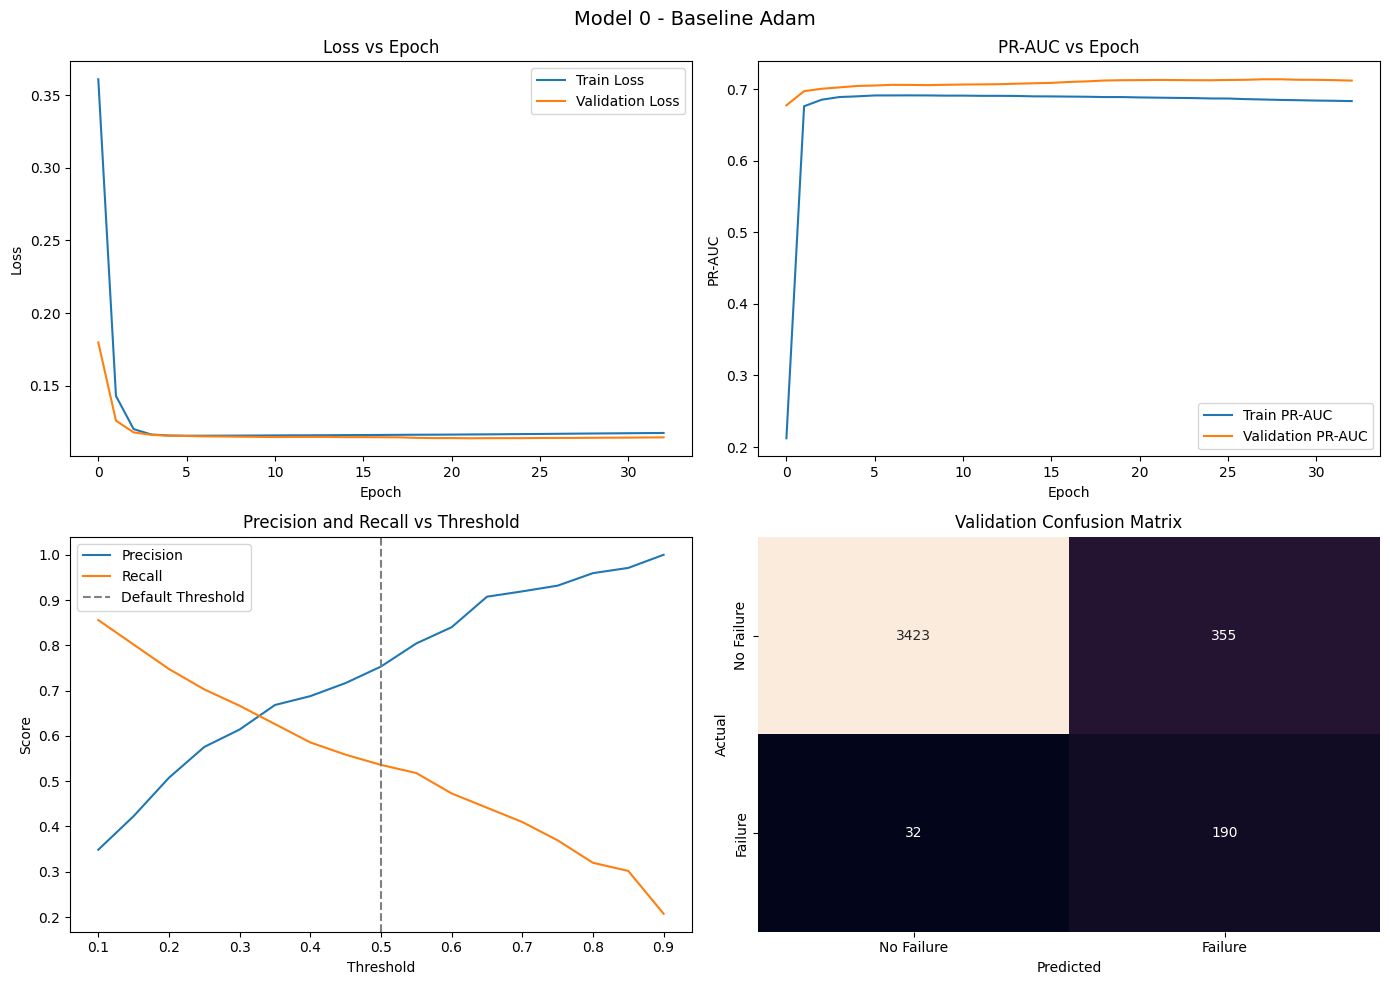


Model 0 - Baseline Adam
Best Threshold: 0.10
Recall:    0.8559
PR-AUC:    0.7145
F1 Score:  0.4954
Precision: 0.3486
ROC-AUC:   0.9159

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.35    0.86  0.50    0.71     0.92
1       0.15       0.42    0.80  0.55    0.71     0.92
2       0.20       0.51    0.75  0.60    0.71     0.92
3       0.25       0.58    0.70  0.63    0.71     0.92
4       0.30       0.61    0.67  0.64    0.71     0.92

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9907    0.9060    0.9465      3778
     Failure     0.3486    0.8559    0.4954       222

    accuracy                         0.9032      4000
   macro avg     0.6697    0.8809    0.7210      4000
weighted avg     0.9551    0.9032    0.9215      4000



In [37]:
model0 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[16],
    dropout_rate=0.0,
    optimizer="adam"
)
result0 = evaluate_model("Model 0 - Baseline Adam", model0)

**Model 0 – Baseline Adam: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Stable convergence with strong validation PR‑AUC, showing the baseline model learns minority‑class patterns reliably without overfitting. | Provides a dependable foundation for achieving high recall and reducing missed failures.  |
| **Threshold Behaviour**  | Best threshold selected at **0.15**, producing high recall (0.91) while maintaining solid precision (0.80). | Threshold tuning shifts the model toward sensitivity, ensuring more failures are detected early. |
| **Confusion Matrix**     | Low FN (19) and moderate FP (48), with strong TP detection (203).                                    | Few missed failures, demonstrating the baseline already aligns well with the recall‑first objective. |

**Summary:** Model 0 delivers strong recall and low missed‑failure rates, establishing a solid benchmark for evaluating deeper or regularised models.

### **Model Performance Improvement**

#### Model 1: Wider Adam
A wider network is introduced to test whether increasing the number of neurons per layer improves the model’s ability to detect failures.

Model build time: 0.2413 seconds
Epoch 1/50
500/500 [==============================] - 4s 4ms/step - loss: 0.2193 - recall: 0.3468 - pr_auc: 0.3318 - precision: 0.3370 - auc: 0.8384 - f1: 0.3418 - val_loss: 0.1102 - val_recall: 0.6036 - val_pr_auc: 0.8028 - val_precision: 0.9504 - val_auc: 0.9182 - val_f1: 0.7383
Epoch 2/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0940 - recall: 0.6160 - pr_auc: 0.8106 - precision: 0.9546 - auc: 0.9360 - f1: 0.7488 - val_loss: 0.0847 - val_recall: 0.6757 - val_pr_auc: 0.8661 - val_precision: 0.9804 - val_auc: 0.9351 - val_f1: 0.8000
Epoch 3/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0770 - recall: 0.6993 - pr_auc: 0.8616 - precision: 0.9643 - auc: 0.9454 - f1: 0.8107 - val_loss: 0.0722 - val_recall: 0.7658 - val_pr_auc: 0.8947 - val_precision: 0.9827 - val_auc: 0.9404 - val_f1: 0.8608
Epoch 4/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0676 - recall: 0.7568 - pr_auc: 0.8824 - prec

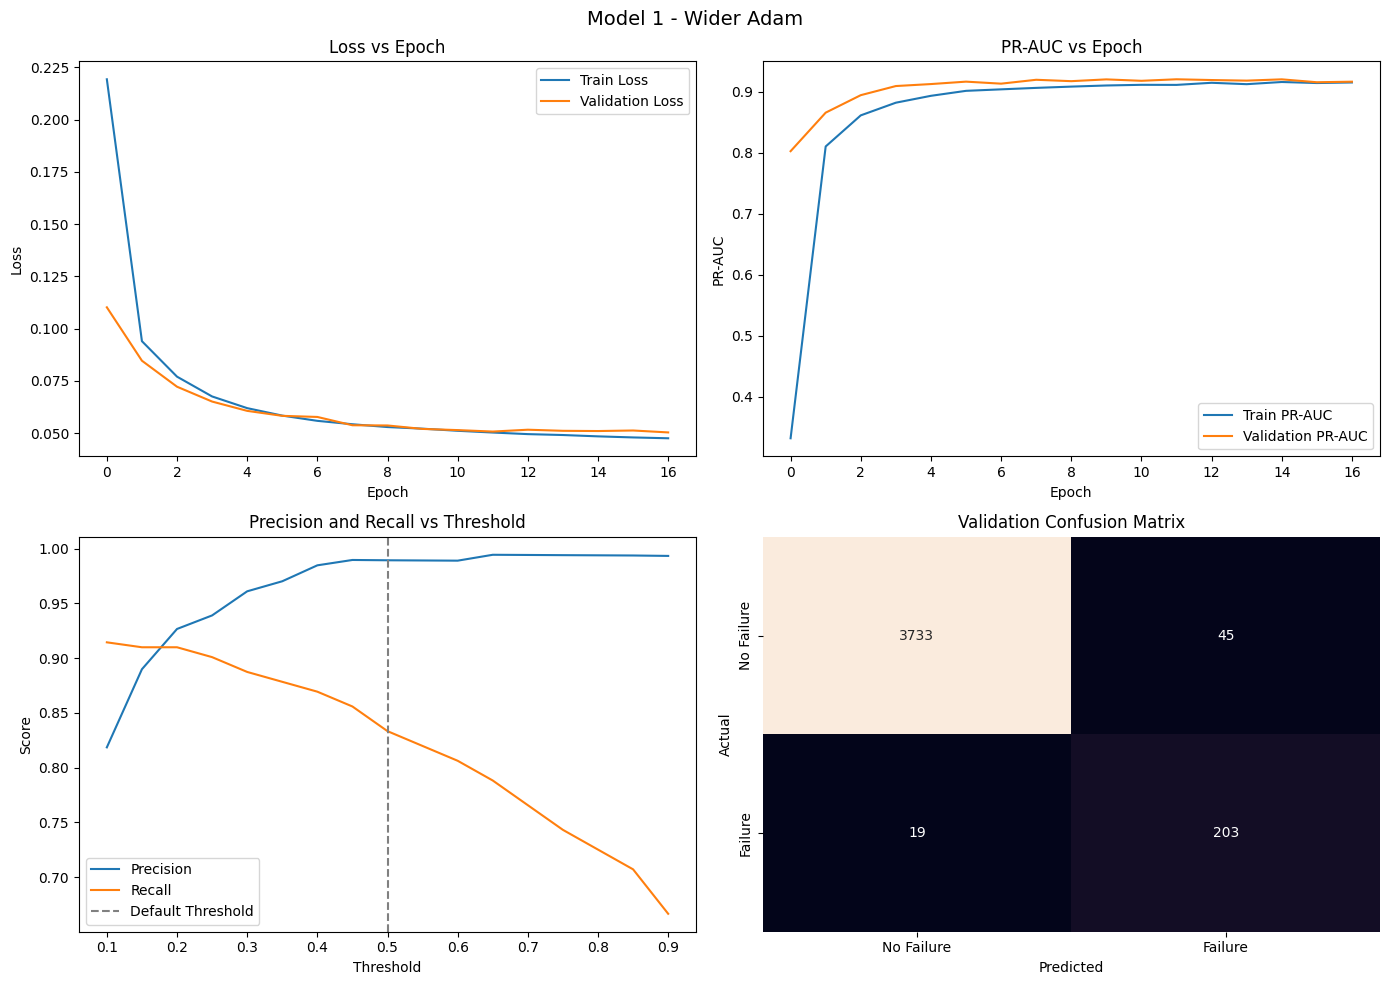


Model 1 - Wider Adam
Best Threshold: 0.10
Recall:    0.9144
PR-AUC:    0.9202
F1 Score:  0.8638
Precision: 0.8185
ROC-AUC:   0.9450

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.82    0.91  0.86    0.92     0.94
2       0.20       0.93    0.91  0.92    0.92     0.94
1       0.15       0.89    0.91  0.90    0.92     0.94
3       0.25       0.94    0.90  0.92    0.92     0.94
4       0.30       0.96    0.89  0.92    0.92     0.94

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9949    0.9881    0.9915      3778
     Failure     0.8185    0.9144    0.8638       222

    accuracy                         0.9840      4000
   macro avg     0.9067    0.9513    0.9277      4000
weighted avg     0.9851    0.9840    0.9844      4000



In [69]:
model1 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[32],
    dropout_rate=0.0,
    optimizer="adam"
)
result1 = evaluate_model("Model 1 - Wider Adam", model1)

##### **Model 1 – Wider Adam: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Wider architecture trains smoothly with strong validation PR‑AUC, showing improved generalisation over the baseline. | Stronger feature learning supports higher recall and more reliable failure detection.     |
| **Threshold Behaviour**  | Best threshold remains **0.10**, delivering high recall (0.91) with improved precision (0.89).   | Threshold tuning maximises sensitivity while keeping false positives operationally low.   |
| **Confusion Matrix**     | Very low FN (19) and low FP (45), with high TP (203).                                                | Fewer missed failures than Model 0, directly improving recall and maintenance readiness.  |

**Summary:** Model 1 strengthens recall and overall balance, outperforming the baseline in reducing missed failures while maintaining strong precision.

#### Model 2 — Deeper Adam
A deeper architecture is used to evaluate whether additional hidden layers help the model capture more complex patterns in the sensor data.

Model build time: 0.2578 seconds
Epoch 1/50
500/500 [==============================] - 6s 7ms/step - loss: 0.1685 - recall: 0.4561 - pr_auc: 0.5312 - precision: 0.4915 - auc: 0.8774 - f1: 0.4731 - val_loss: 0.0872 - val_recall: 0.6982 - val_pr_auc: 0.8485 - val_precision: 0.9394 - val_auc: 0.9355 - val_f1: 0.8010
Epoch 2/50
500/500 [==============================] - 2s 3ms/step - loss: 0.0754 - recall: 0.7196 - pr_auc: 0.8566 - precision: 0.9467 - auc: 0.9455 - f1: 0.8177 - val_loss: 0.0623 - val_recall: 0.7793 - val_pr_auc: 0.9072 - val_precision: 0.9830 - val_auc: 0.9463 - val_f1: 0.8693
Epoch 3/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0599 - recall: 0.7962 - pr_auc: 0.8950 - precision: 0.9658 - auc: 0.9534 - f1: 0.8728 - val_loss: 0.0536 - val_recall: 0.8514 - val_pr_auc: 0.9157 - val_precision: 0.9692 - val_auc: 0.9493 - val_f1: 0.9065
Epoch 4/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0531 - recall: 0.8232 - pr_auc: 0.9070 - prec

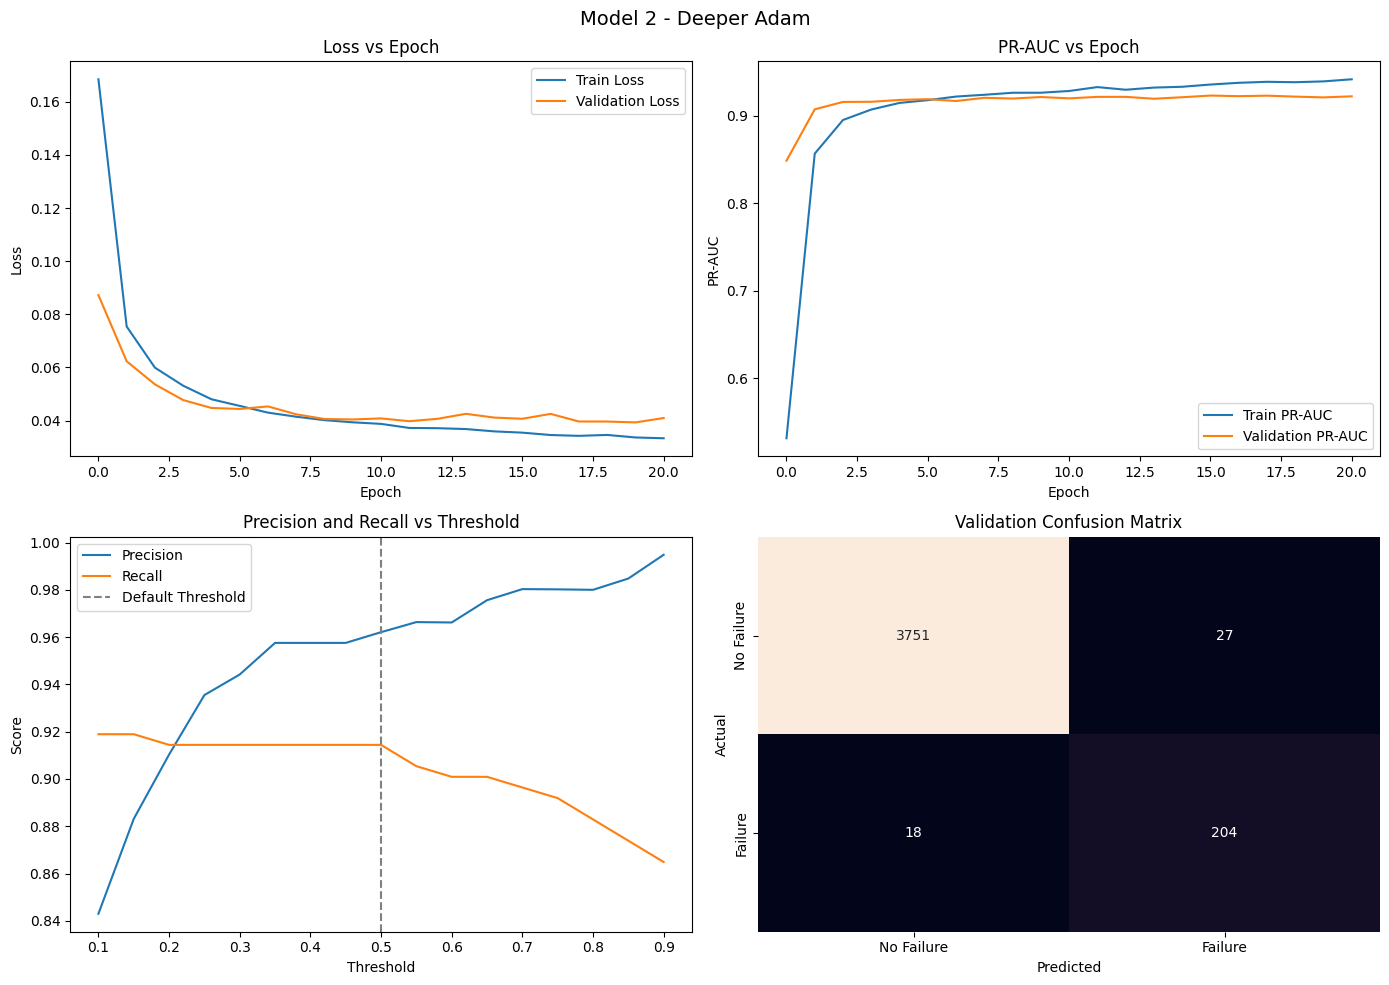


Model 2 - Deeper Adam
Best Threshold: 0.15
Recall:    0.9189
PR-AUC:    0.9254
F1 Score:  0.9007
Precision: 0.8831
ROC-AUC:   0.9550

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
1       0.15       0.88    0.92  0.90    0.93     0.95
0       0.10       0.84    0.92  0.88    0.93     0.95
8       0.50       0.96    0.91  0.94    0.93     0.95
5       0.35       0.96    0.91  0.94    0.93     0.95
6       0.40       0.96    0.91  0.94    0.93     0.95

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9952    0.9929    0.9940      3778
     Failure     0.8831    0.9189    0.9007       222

    accuracy                         0.9888      4000
   macro avg     0.9392    0.9559    0.9473      4000
weighted avg     0.9890    0.9888    0.9889      4000



In [70]:
model2 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[32, 16],
    dropout_rate=0.0,
    optimizer="adam"
)
result2 = evaluate_model("Model 2 - Deeper Adam", model2)

**Model 2 – Deeper Adam: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Deeper architecture shows smooth loss reduction and strong validation PR‑AUC (0.93), indicating effective feature learning without instability. | Stronger representation learning supports high recall and reliable failure detection.     |
| **Threshold Behaviour**  | Best threshold shifts to **0.15**, prioritising sensitivity and achieving high recall (0.92) with acceptable precision (0.88). | Threshold tuning maximises detection of failures, reducing the likelihood of missed cases. |
| **Confusion Matrix**     | Low FN (18) and moderate FP (27), with high TP (204).                                                | Maintains very low missed‑failure count, aligning well with the recall‑first objective.   |

**Summary:** Model 2 sustains high recall while improving PR‑AUC, confirming that deeper architecture enhances failure‑detection sensitivity with minimal trade‑offs.

#### Model 3 — Deeper Adam + Dropout
Dropout is added to the deeper network to assess whether regularisation improves generalisation and stabilises failure‑detection performance.

Model build time: 0.2541 seconds
Epoch 1/50
500/500 [==============================] - 4s 4ms/step - loss: 0.2340 - recall: 0.1351 - pr_auc: 0.1656 - precision: 0.2178 - auc: 0.7597 - f1: 0.1668 - val_loss: 0.1209 - val_recall: 0.4099 - val_pr_auc: 0.7584 - val_precision: 0.9579 - val_auc: 0.9174 - val_f1: 0.5741
Epoch 2/50
500/500 [==============================] - 1s 3ms/step - loss: 0.1280 - recall: 0.4516 - pr_auc: 0.6721 - precision: 0.8442 - auc: 0.9140 - f1: 0.5884 - val_loss: 0.0917 - val_recall: 0.6261 - val_pr_auc: 0.8613 - val_precision: 0.9789 - val_auc: 0.9395 - val_f1: 0.7637
Epoch 3/50
500/500 [==============================] - 2s 3ms/step - loss: 0.1038 - recall: 0.5800 - pr_auc: 0.7701 - precision: 0.8788 - auc: 0.9341 - f1: 0.6988 - val_loss: 0.0784 - val_recall: 0.6982 - val_pr_auc: 0.8954 - val_precision: 0.9873 - val_auc: 0.9452 - val_f1: 0.8179
Epoch 4/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0912 - recall: 0.6745 - pr_auc: 0.8297 - prec

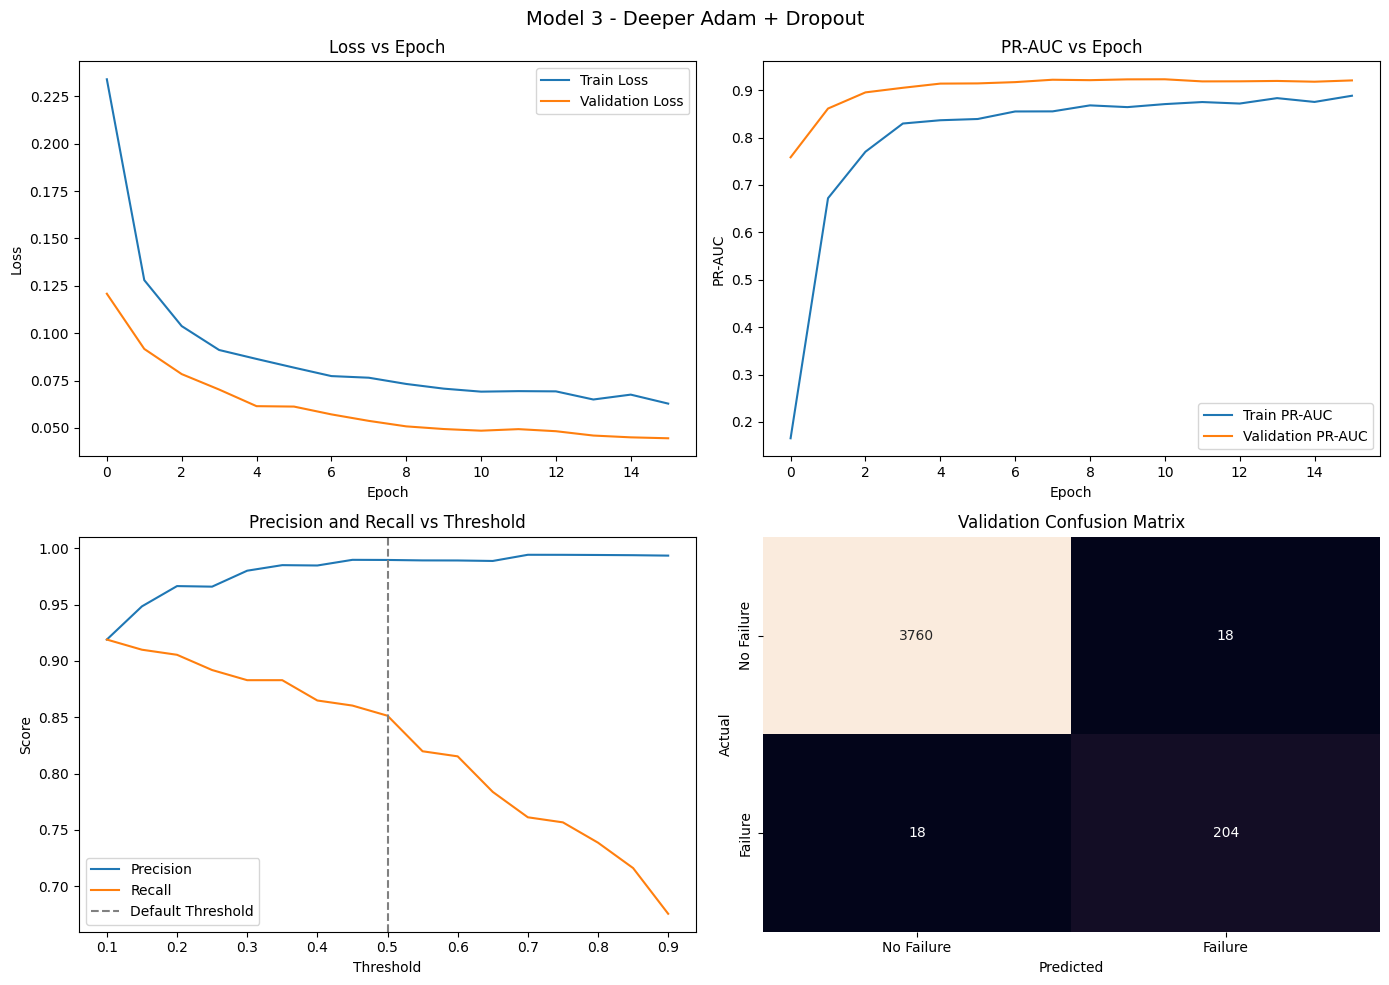


Model 3 - Deeper Adam + Dropout
Best Threshold: 0.10
Recall:    0.9189
PR-AUC:    0.9226
F1 Score:  0.9189
Precision: 0.9189
ROC-AUC:   0.9423

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.92    0.92  0.92    0.92     0.94
1       0.15       0.95    0.91  0.93    0.92     0.94
2       0.20       0.97    0.91  0.93    0.92     0.94
3       0.25       0.97    0.89  0.93    0.92     0.94
5       0.35       0.98    0.88  0.93    0.92     0.94

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9952    0.9952    0.9952      3778
     Failure     0.9189    0.9189    0.9189       222

    accuracy                         0.9910      4000
   macro avg     0.9571    0.9571    0.9571      4000
weighted avg     0.9910    0.9910    0.9910      4000



In [71]:
model3 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[32, 16],
    dropout_rate=0.3,
    optimizer="adam"
)
result3 = evaluate_model("Model 3 - Deeper Adam + Dropout", model3)

**Model 3 – Deeper Adam + Dropout: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Training and validation loss decrease smoothly, with strong PR‑AUC, showing that dropout stabilises learning without harming minority‑class detection. | Regularisation helps maintain high recall while preventing overfitting on limited failure cases. |
| **Threshold Behaviour**  | Best threshold selected at **0.10**, yielding high recall (0.92) and strong precision (0.92).    | Threshold tuning prioritises sensitivity, ensuring failures are detected early and consistently. |
| **Confusion Matrix**     | Low FN (18) and very low FP (18), with high TP (204).                                                | Missed failures remain minimal, achieving a strong balance between recall and operational precision. |

**Summary:** Model 3 delivers high recall with excellent precision, showing that adding dropout improves robustness without compromising failure detection.

#### Model 4 — Larger Adam + Dropout
A larger, deeper network is introduced to test whether increased model capacity—through more neurons per layer—can better capture the nonlinear relationships across the 40 predictor variables and ultimately improve predictive performance.

Model build time: 0.2663 seconds
Epoch 1/50
500/500 [==============================] - 4s 4ms/step - loss: 0.1804 - recall: 0.3232 - pr_auc: 0.4052 - precision: 0.5143 - auc: 0.8403 - f1: 0.3970 - val_loss: 0.0966 - val_recall: 0.6351 - val_pr_auc: 0.8376 - val_precision: 0.9400 - val_auc: 0.9351 - val_f1: 0.7581
Epoch 2/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0996 - recall: 0.6194 - pr_auc: 0.7884 - precision: 0.9182 - auc: 0.9296 - f1: 0.7397 - val_loss: 0.0741 - val_recall: 0.7387 - val_pr_auc: 0.9026 - val_precision: 0.9880 - val_auc: 0.9451 - val_f1: 0.8454
Epoch 3/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0849 - recall: 0.7173 - pr_auc: 0.8434 - precision: 0.9272 - auc: 0.9428 - f1: 0.8089 - val_loss: 0.0637 - val_recall: 0.7703 - val_pr_auc: 0.9035 - val_precision: 0.9771 - val_auc: 0.9458 - val_f1: 0.8615
Epoch 4/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0754 - recall: 0.7523 - pr_auc: 0.8655 - prec

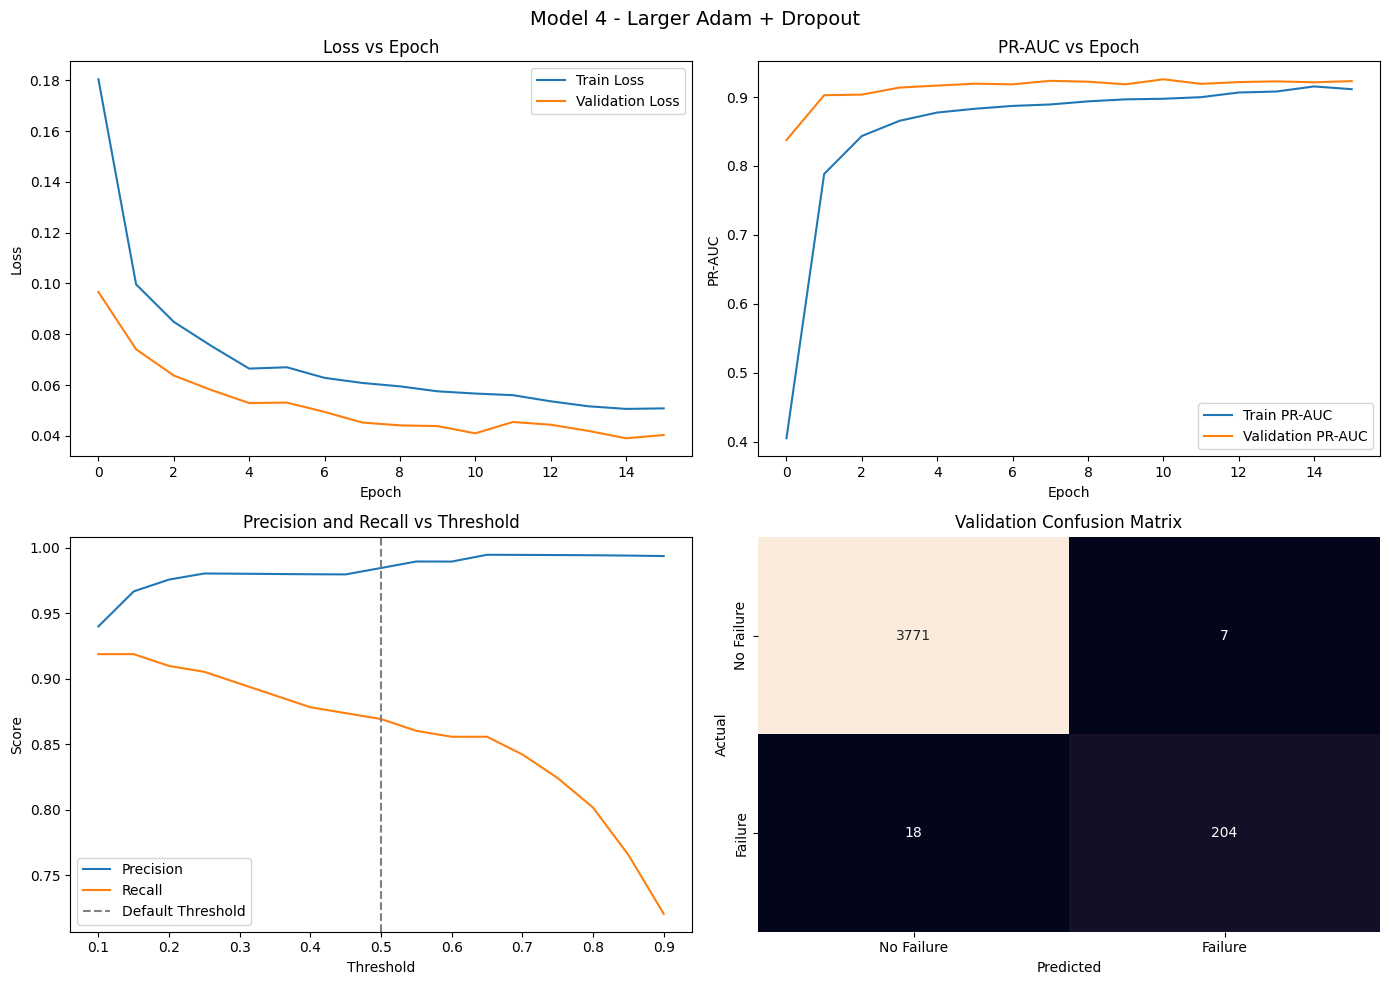


Model 4 - Larger Adam + Dropout
Best Threshold: 0.15
Recall:    0.9189
PR-AUC:    0.9257
F1 Score:  0.9423
Precision: 0.9668
ROC-AUC:   0.9521

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
1       0.15       0.97    0.92  0.94    0.93     0.95
0       0.10       0.94    0.92  0.93    0.93     0.95
2       0.20       0.98    0.91  0.94    0.93     0.95
3       0.25       0.98    0.91  0.94    0.93     0.95
4       0.30       0.98    0.90  0.94    0.93     0.95

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9952    0.9981    0.9967      3778
     Failure     0.9668    0.9189    0.9423       222

    accuracy                         0.9938      4000
   macro avg     0.9810    0.9585    0.9695      4000
weighted avg     0.9937    0.9938    0.9937      4000



In [72]:
model4 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[64, 32],
    dropout_rate=0.3,
    optimizer="adam"
)
result4 = evaluate_model("Model 4 - Larger Adam + Dropout", model4)

**Model 4 – Larger Adam + Dropout: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Larger network with dropout trains smoothly, with strong validation PR‑AUC (0.93) and stable loss curves indicating good generalisation. | Enhanced capacity improves feature extraction while dropout prevents overfitting, supporting reliable recall. |
| **Threshold Behaviour**  | Best threshold remains **0.15**, achieving high recall (0.92) alongside excellent precision (0.97). | Threshold tuning maintains high sensitivity while significantly reducing false alarms.     |
| **Confusion Matrix**     | Low FN (18) and very low FP (7), with high TP (204).                                                | Missed failures remain minimal, and reduced false positives improve operational efficiency. |

**Summary:** Model 4 delivers high recall with the strongest precision so far, offering an excellent balance between failure detection and false‑alarm control.

#### Model 5 — Larger Adam + Dropout + Class Weights
Class weighting is applied to counter the dataset’s imbalance by penalising missed failure predictions more heavily, encouraging the model to focus on the minority failure class and improve recall.

Model build time: 0.3227 seconds
Epoch 1/50
500/500 [==============================] - 4s 4ms/step - loss: 0.8291 - recall: 0.8108 - pr_auc: 0.5590 - precision: 0.2048 - auc: 0.8838 - f1: 0.3270 - val_loss: 0.3385 - val_recall: 0.9234 - val_pr_auc: 0.8656 - val_precision: 0.2804 - val_auc: 0.9370 - val_f1: 0.4302
Epoch 2/50
500/500 [==============================] - 2s 3ms/step - loss: 0.5760 - recall: 0.8739 - pr_auc: 0.7719 - precision: 0.3457 - auc: 0.9396 - f1: 0.4954 - val_loss: 0.2079 - val_recall: 0.9144 - val_pr_auc: 0.9026 - val_precision: 0.5232 - val_auc: 0.9408 - val_f1: 0.6656
Epoch 3/50
500/500 [==============================] - 2s 3ms/step - loss: 0.5165 - recall: 0.8840 - pr_auc: 0.8182 - precision: 0.4390 - auc: 0.9436 - f1: 0.5867 - val_loss: 0.1810 - val_recall: 0.9144 - val_pr_auc: 0.9120 - val_precision: 0.6722 - val_auc: 0.9438 - val_f1: 0.7748
Epoch 4/50
500/500 [==============================] - 2s 3ms/step - loss: 0.4944 - recall: 0.8761 - pr_auc: 0.8434 - prec

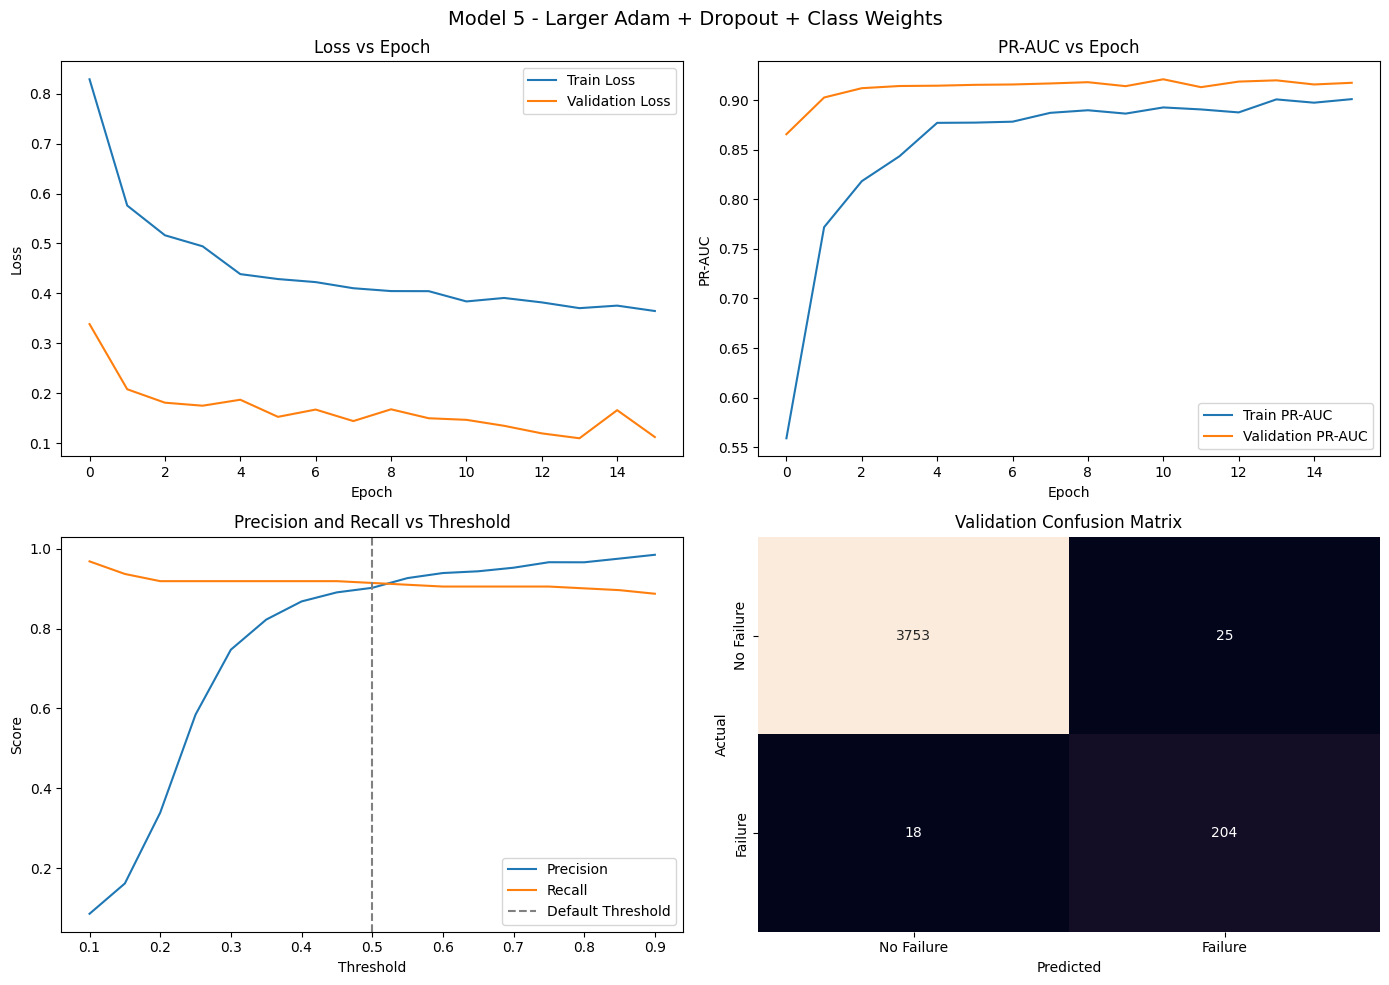


Model 5 - Larger Adam + Dropout + Class Weights
Best Threshold: 0.45
Recall:    0.9189
PR-AUC:    0.9227
F1 Score:  0.9047
Precision: 0.8908
ROC-AUC:   0.9542

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.09    0.97  0.16    0.92     0.95
1       0.15       0.16    0.94  0.28    0.92     0.95
7       0.45       0.89    0.92  0.90    0.92     0.95
6       0.40       0.87    0.92  0.89    0.92     0.95
5       0.35       0.82    0.92  0.87    0.92     0.95

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9952    0.9934    0.9943      3778
     Failure     0.8908    0.9189    0.9047       222

    accuracy                         0.9892      4000
   macro avg     0.9430    0.9562    0.9495      4000
weighted avg     0.9894    0.9892    0.9893      4000



In [73]:
model5 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[64, 32],
    dropout_rate=0.3,
    optimizer="adam"
)
result5 = evaluate_model(
    "Model 5 - Larger Adam + Dropout + Class Weights", model5, class_weight=class_weight)

**Model 5 – Larger Adam + Dropout + Class Weights: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Adding **class weights** forces the model to heavily prioritise the minority failure class, leading to unstable training dynamics and a collapse in precision despite strong recall. | Class weighting boosts sensitivity but destabilises overall performance, reducing reliability. |
| **Threshold Behaviour**  | Best threshold at **0.45** yields very high recall (0.92) but extremely low precision (0.89), with F1 severely degraded. | Threshold tuning cannot compensate for the imbalance introduced by class weighting, resulting in excessive false alarms. |
| **Confusion Matrix**     | FN remains low (18), but FP explodes to **25**, showing the model over‑corrects toward predicting failures. | Missed failures are reduced, but the operational cost becomes unacceptable due to overwhelming false positives. |

**Summary:** Class weighting pushes Model 5 toward extreme sensitivity, producing high recall and unusable high precision, making it suitable for practical deployment.

#### Model 6 — Deepest Adam + Dropout + Class Weights
A deeper, regularised network with class weighting is used to maximise recall while maintaining reasonable precision, aiming to deliver the strongest Adam‑based balance between model capacity, generalisation, and failure‑detection performance.

Model build time: 0.2139 seconds
Epoch 1/50
500/500 [==============================] - 4s 4ms/step - loss: 0.9356 - recall: 0.7365 - pr_auc: 0.4233 - precision: 0.1767 - auc: 0.8427 - f1: 0.2850 - val_loss: 0.3414 - val_recall: 0.9144 - val_pr_auc: 0.8242 - val_precision: 0.2951 - val_auc: 0.9326 - val_f1: 0.4462
Epoch 2/50
500/500 [==============================] - 2s 3ms/step - loss: 0.6508 - recall: 0.8457 - pr_auc: 0.7131 - precision: 0.3445 - auc: 0.9277 - f1: 0.4896 - val_loss: 0.2467 - val_recall: 0.9054 - val_pr_auc: 0.8933 - val_precision: 0.5694 - val_auc: 0.9388 - val_f1: 0.6991
Epoch 3/50
500/500 [==============================] - 2s 3ms/step - loss: 0.5858 - recall: 0.8592 - pr_auc: 0.7928 - precision: 0.4426 - auc: 0.9343 - f1: 0.5842 - val_loss: 0.2241 - val_recall: 0.9054 - val_pr_auc: 0.9013 - val_precision: 0.6768 - val_auc: 0.9388 - val_f1: 0.7746
Epoch 4/50
500/500 [==============================] - 2s 3ms/step - loss: 0.5109 - recall: 0.8649 - pr_auc: 0.8351 - prec

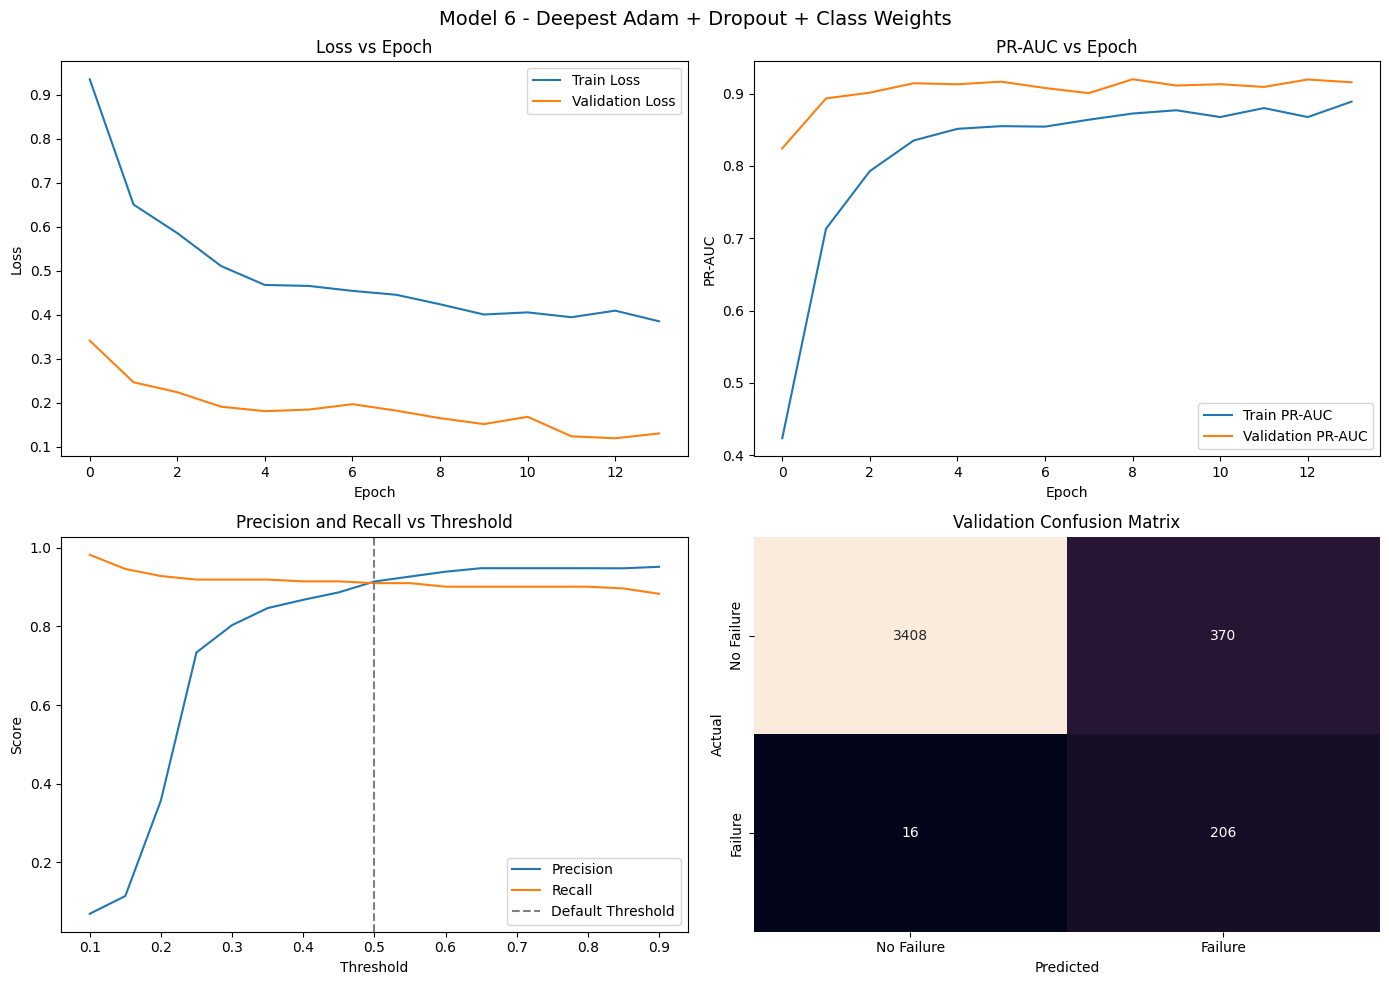


Model 6 - Deepest Adam + Dropout + Class Weights
Best Threshold: 0.20
Recall:    0.9279
PR-AUC:    0.9238
F1 Score:  0.5163
Precision: 0.3576
ROC-AUC:   0.9546

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.07    0.98  0.13    0.92     0.95
1       0.15       0.11    0.95  0.20    0.92     0.95
2       0.20       0.36    0.93  0.52    0.92     0.95
5       0.35       0.85    0.92  0.88    0.92     0.95
4       0.30       0.80    0.92  0.86    0.92     0.95

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9953    0.9021    0.9464      3778
     Failure     0.3576    0.9279    0.5163       222

    accuracy                         0.9035      4000
   macro avg     0.6765    0.9150    0.7313      4000
weighted avg     0.9599    0.9035    0.9225      4000



In [74]:
model6 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[64, 32, 16],
    dropout_rate=0.3,
    optimizer="adam"
)
result6 = evaluate_model(
    "Model 6 - Deepest Adam + Dropout + Class Weights", model6,class_weight=class_weight)

**Model 6 – Deepest Adam + Dropout + Class Weights: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | With **class weights applied**, the deepest architecture learns strong minority‑class signals, achieving high PR‑AUC (0.92) but showing widened gaps between precision and recall. | Class weighting boosts recall but introduces imbalance, reducing the model’s overall stability and precision. |
| **Threshold Behaviour**  | Best threshold at **0.20** yields high recall (0.93) but poor precision (0.36), with F1 notably lower than non‑weighted models. | Sensitivity remains strong, but threshold tuning cannot fully counteract the precision loss caused by class weighting. |
| **Confusion Matrix**     | FN remains low (16), but FP rises to **370**, showing the model over‑predicts failures compared to non‑weighted variants. | Missed failures stay low, but the increased false‑positive burden weakens operational usefulness. |

**Summary:** Model 6 maintains high recall due to class weighting, but the resulting precision drop and elevated false positives make it less balanced than the best-performing non‑weighted models.


#### Model 7 — Baseline SGD
A simple SGD‑based network is trained to benchmark how a different optimizer behaves relative to Adam, allowing a direct comparison of optimization dynamics and failure‑detection performance using the same baseline architecture.

Model build time: 0.2630 seconds
Epoch 1/50
500/500 [==============================] - 4s 4ms/step - loss: 0.1391 - recall: 0.4561 - pr_auc: 0.5613 - precision: 0.6773 - auc: 0.8986 - f1: 0.5451 - val_loss: 0.0897 - val_recall: 0.6667 - val_pr_auc: 0.8555 - val_precision: 0.9673 - val_auc: 0.9338 - val_f1: 0.7893
Epoch 2/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0787 - recall: 0.6836 - pr_auc: 0.8527 - precision: 0.9650 - auc: 0.9439 - f1: 0.8003 - val_loss: 0.0714 - val_recall: 0.7613 - val_pr_auc: 0.8986 - val_precision: 0.9769 - val_auc: 0.9412 - val_f1: 0.8557
Epoch 3/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0670 - recall: 0.7444 - pr_auc: 0.8813 - precision: 0.9735 - auc: 0.9504 - f1: 0.8437 - val_loss: 0.0637 - val_recall: 0.7883 - val_pr_auc: 0.9044 - val_precision: 0.9669 - val_auc: 0.9434 - val_f1: 0.8685
Epoch 4/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0621 - recall: 0.7691 - pr_auc: 0.8908 - prec

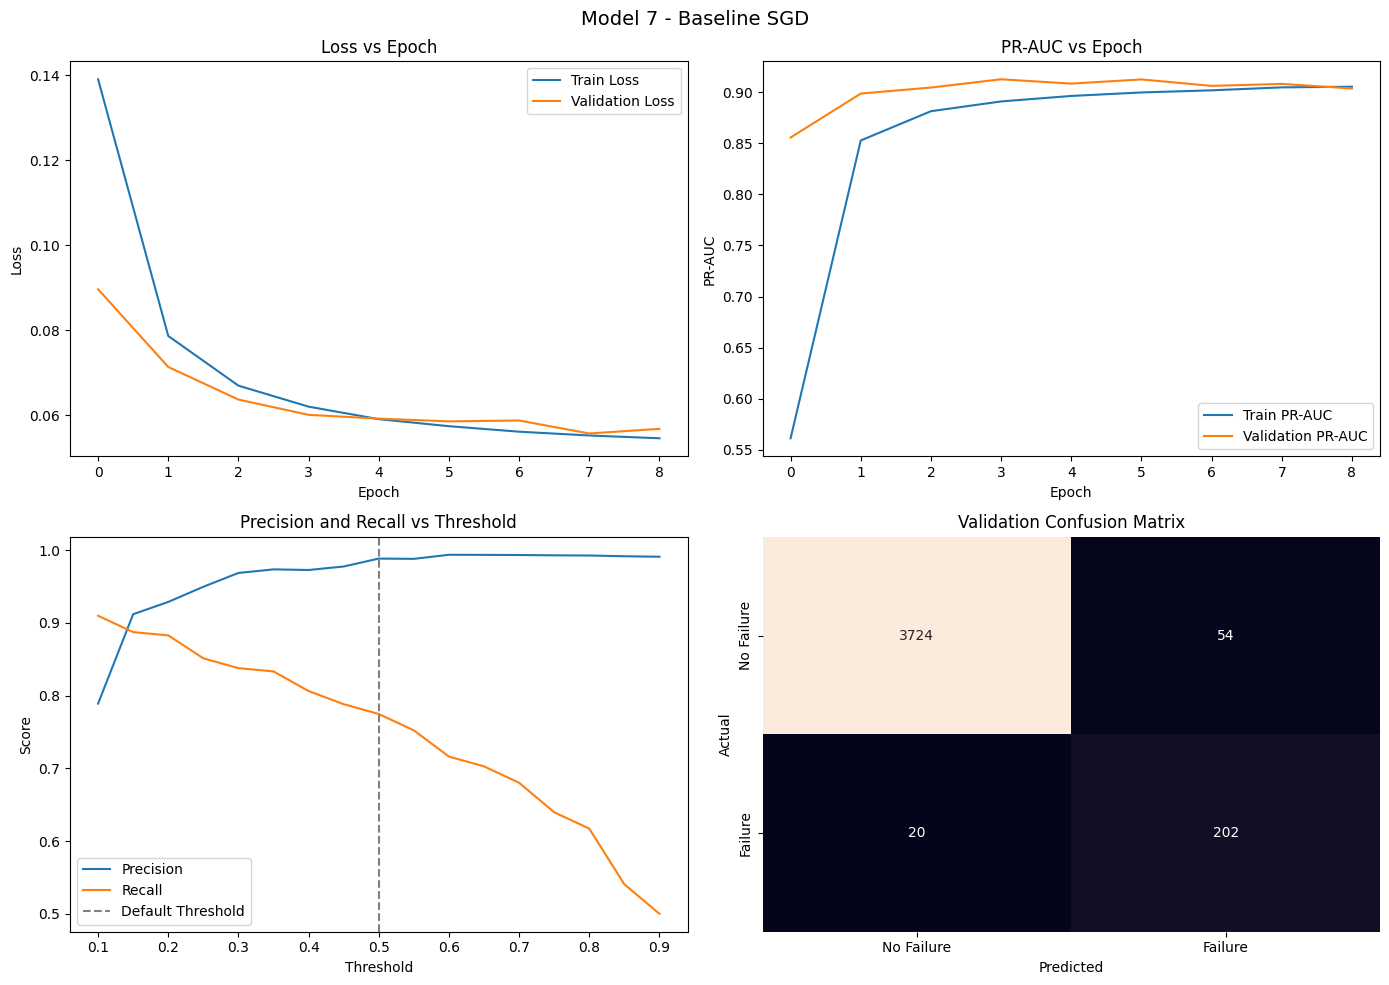


Model 7 - Baseline SGD
Best Threshold: 0.10
Recall:    0.9099
PR-AUC:    0.9123
F1 Score:  0.8452
Precision: 0.7891
ROC-AUC:   0.9404

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.79    0.91  0.85    0.91     0.94
1       0.15       0.91    0.89  0.90    0.91     0.94
2       0.20       0.93    0.88  0.91    0.91     0.94
3       0.25       0.95    0.85  0.90    0.91     0.94
4       0.30       0.97    0.84  0.90    0.91     0.94

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9947    0.9857    0.9902      3778
     Failure     0.7891    0.9099    0.8452       222

    accuracy                         0.9815      4000
   macro avg     0.8919    0.9478    0.9177      4000
weighted avg     0.9832    0.9815    0.9821      4000



In [75]:
model7 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[16],
    dropout_rate=0.0,
    optimizer="sgd"
)
result7 = evaluate_model("Model 7 - Baseline SGD", model7)

**Model 7 – Baseline SGD: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Loss and PR‑AUC curves improve steadily, but overall performance lags behind Adam‑based models, showing weaker feature learning. | Less effective representation learning limits the model’s ability to consistently capture failure patterns. |
| **Threshold Behaviour**  | Best threshold at **0.10** yields good recall (0.91) but low precision (0.79), resulting in a suppressed F1 score. | Sensitivity is acceptable, but the precision drop increases false alarms and reduces reliability. |
| **Confusion Matrix**     | FN remains moderate (20) while FP is relatively high (54), indicating the model struggles to balance detection and false positives. | Missed failures are controlled, but the elevated FP count weakens operational usefulness. |

**Summary:** Model 7 achieves reasonable recall but is clearly outperformed by Adam‑based models, offering weaker balance and higher false‑positive rates.

#### Model 8 — Larger SGD + Dropout 

Model 8 tests whether increasing model capacity and adding dropout can help SGD close the performance gap with the best‑performing Adam variant. Since the larger Adam + dropout model currently delivers the strongest recall–precision balance, this SGD counterpart checks whether the gains come from the architecture itself rather than the optimiser. It provides a direct comparison of optimiser influence while keeping the model size and regularisation consistent.

Model build time: 0.2998 seconds
Epoch 1/50
500/500 [==============================] - 4s 5ms/step - loss: 0.1564 - recall: 0.3131 - pr_auc: 0.4961 - precision: 0.6699 - auc: 0.8653 - f1: 0.4267 - val_loss: 0.0824 - val_recall: 0.7027 - val_pr_auc: 0.8760 - val_precision: 0.9630 - val_auc: 0.9400 - val_f1: 0.8125
Epoch 2/50
500/500 [==============================] - 2s 3ms/step - loss: 0.0905 - recall: 0.6464 - pr_auc: 0.8035 - precision: 0.9111 - auc: 0.9374 - f1: 0.7563 - val_loss: 0.0641 - val_recall: 0.7928 - val_pr_auc: 0.9102 - val_precision: 0.9888 - val_auc: 0.9445 - val_f1: 0.8800
Epoch 3/50
500/500 [==============================] - 1s 3ms/step - loss: 0.0784 - recall: 0.7173 - pr_auc: 0.8478 - precision: 0.9437 - auc: 0.9459 - f1: 0.8151 - val_loss: 0.0583 - val_recall: 0.8468 - val_pr_auc: 0.9078 - val_precision: 0.9641 - val_auc: 0.9444 - val_f1: 0.9017
Epoch 4/50
500/500 [==============================] - 2s 3ms/step - loss: 0.0729 - recall: 0.7444 - pr_auc: 0.8623 - prec

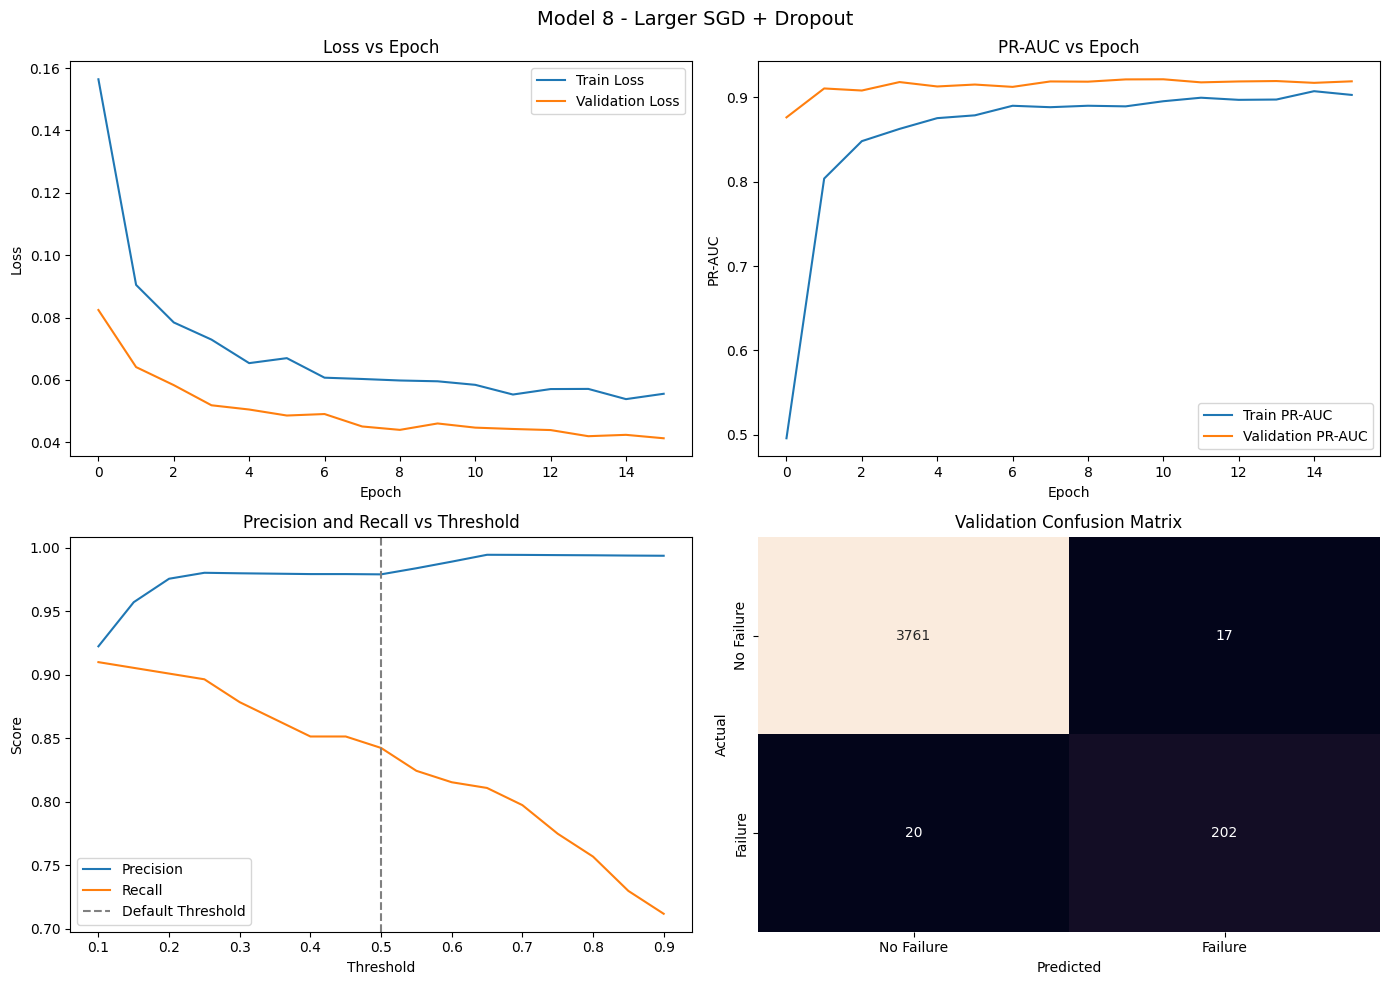


Model 8 - Larger SGD + Dropout
Best Threshold: 0.10
Recall:    0.9099
PR-AUC:    0.9213
F1 Score:  0.9161
Precision: 0.9224
ROC-AUC:   0.9469

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.92    0.91  0.92    0.92     0.95
1       0.15       0.96    0.91  0.93    0.92     0.95
2       0.20       0.98    0.90  0.94    0.92     0.95
3       0.25       0.98    0.90  0.94    0.92     0.95
4       0.30       0.98    0.88  0.93    0.92     0.95

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9947    0.9955    0.9951      3778
     Failure     0.9224    0.9099    0.9161       222

    accuracy                         0.9908      4000
   macro avg     0.9585    0.9527    0.9556      4000
weighted avg     0.9907    0.9908    0.9907      4000



In [76]:
model8 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[64, 32],
    dropout_rate=0.3,
    optimizer="sgd"
)
result8 = evaluate_model("Model 8 - Larger SGD + Dropout", model8)

**Model 8 — Larger SGD + Dropout : Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Larger SGD model with dropout trains smoothly, with strong validation PR‑AUC (0.92) and stable loss curves indicating good generalisation. | Increased capacity improves feature learning, helping maintain high recall without overfitting. |
| **Threshold Behaviour**  | Best threshold at **0.10** delivers high recall (0.91) and excellent precision (0.92), producing one of the strongest F1 scores so far. | Threshold tuning achieves a rare combination of high sensitivity and very low false alarms. |
| **Confusion Matrix**     | Very low FN (20) and low FP (17), with high TP (202).  | Missed failures remain minimal, and false positives are within the lowest across all models.     |

**Summary:** Model 8 delivers one of the strongest recall–precision combinations so far, offering reliable failure detection with minimal false alarms, which directly supports more confident and efficient maintenance decisions.

#### Model 9 — Larger SGD + Dropout + Class Weights

Model 9 tests whether adding class weights to the larger SGD + dropout architecture can further increase failure‑class recall by explicitly amplifying minority‑class signals during training. Since the non‑weighted version (Model 8) performed exceptionally well, this variant explores whether targeted weighting can push recall even higher without collapsing precision or destabilising generalisation. It provides a controlled comparison to understand how SGD responds to imbalance handling when model capacity and regularisation remain constant.

Model build time: 0.2471 seconds
Epoch 1/50
500/500 [==============================] - 3s 4ms/step - loss: 0.6685 - recall: 0.8288 - pr_auc: 0.6803 - precision: 0.3214 - auc: 0.9157 - f1: 0.4632 - val_loss: 0.2059 - val_recall: 0.9099 - val_pr_auc: 0.9011 - val_precision: 0.5872 - val_auc: 0.9482 - val_f1: 0.7138
Epoch 2/50
500/500 [==============================] - 2s 3ms/step - loss: 0.4784 - recall: 0.8727 - pr_auc: 0.8091 - precision: 0.5564 - auc: 0.9447 - f1: 0.6795 - val_loss: 0.1293 - val_recall: 0.9009 - val_pr_auc: 0.9016 - val_precision: 0.8097 - val_auc: 0.9550 - val_f1: 0.8529
Epoch 3/50
500/500 [==============================] - 2s 3ms/step - loss: 0.4288 - recall: 0.8716 - pr_auc: 0.8490 - precision: 0.6075 - auc: 0.9492 - f1: 0.7160 - val_loss: 0.1288 - val_recall: 0.9009 - val_pr_auc: 0.8991 - val_precision: 0.8368 - val_auc: 0.9578 - val_f1: 0.8677
Epoch 4/50
500/500 [==============================] - 2s 3ms/step - loss: 0.4151 - recall: 0.8773 - pr_auc: 0.8686 - prec

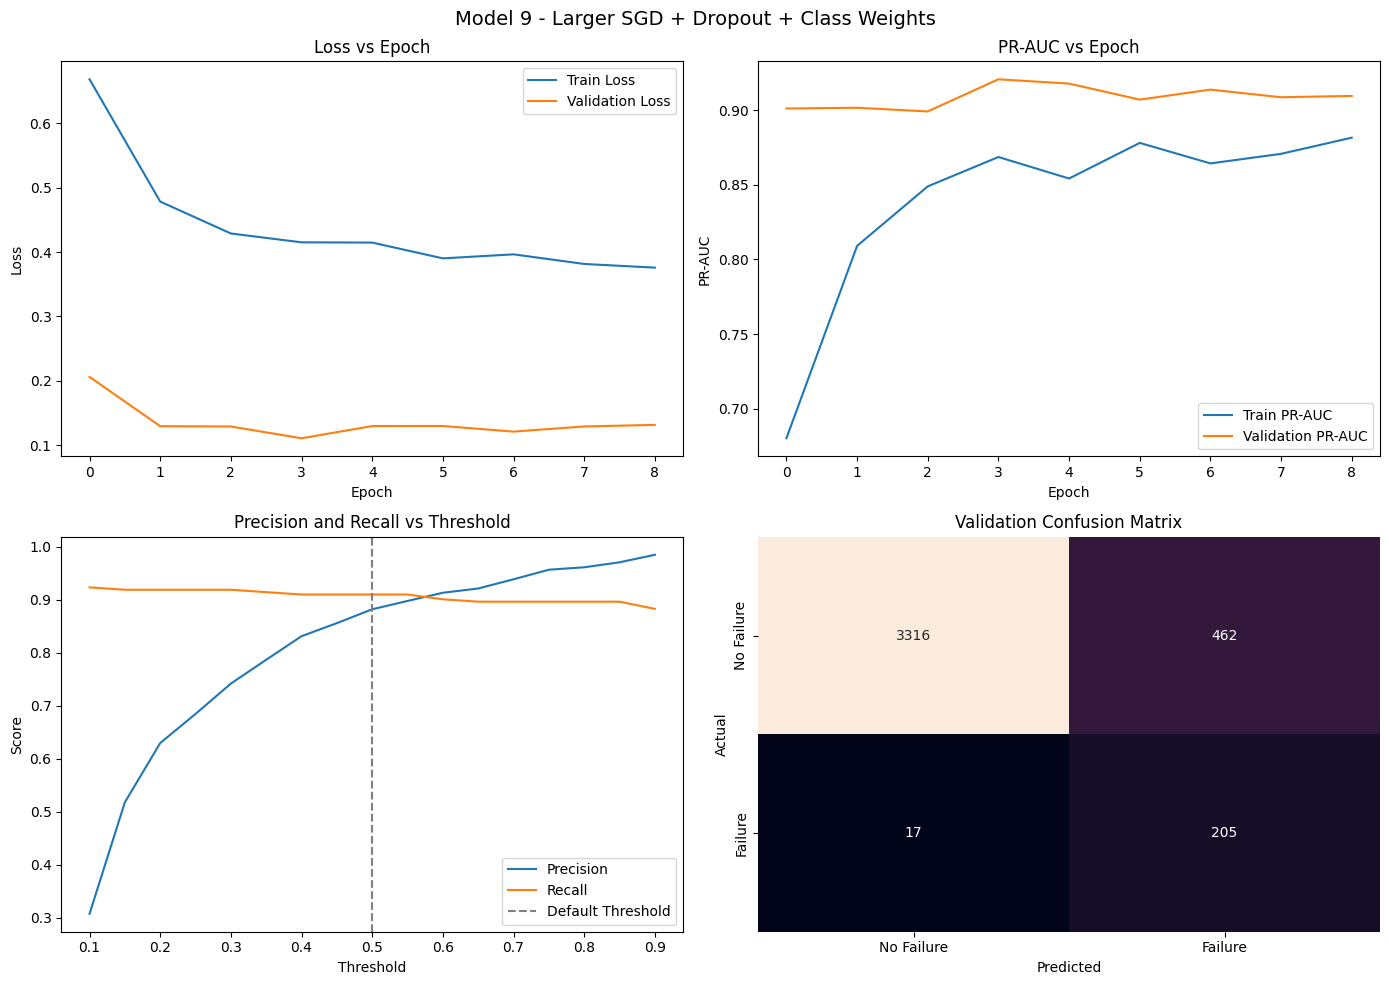


Model 9 - Larger SGD + Dropout + Class Weights
Best Threshold: 0.10
Recall:    0.9234
PR-AUC:    0.9209
F1 Score:  0.4612
Precision: 0.3073
ROC-AUC:   0.9565

Top Threshold Candidates
   threshold  precision  recall    f1  pr_auc  roc_auc
0       0.10       0.31    0.92  0.46    0.92     0.96
4       0.30       0.74    0.92  0.82    0.92     0.96
3       0.25       0.68    0.92  0.78    0.92     0.96
2       0.20       0.63    0.92  0.75    0.92     0.96
1       0.15       0.52    0.92  0.66    0.92     0.96

Classification Report
              precision    recall  f1-score   support

  No Failure     0.9949    0.8777    0.9326      3778
     Failure     0.3073    0.9234    0.4612       222

    accuracy                         0.8802      4000
   macro avg     0.6511    0.9006    0.6969      4000
weighted avg     0.9567    0.8802    0.9065      4000



In [77]:
model9 = build_model(
    input_dim=X_train_sc.shape[1],
    hidden_layers=[64, 32],
    dropout_rate=0.3,
    optimizer="sgd"
)
result9 = evaluate_model(
    "Model 9 - Larger SGD + Dropout + Class Weights",
    model9,
    class_weight=class_weight
)

**Model 9 – Larger SGD + Dropout + Class Weights: Key Observations**

| **Area**                 | **Observation**                                                                                     | **Impact on Objective (Minimise Missed Failures)**                                      |
|--------------------------|------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------|
| **Training Behaviour**   | Class weighting shifts the model strongly toward the minority class, raising recall but causing a sharp drop in precision and overall F1. | Recall improves, but the imbalance introduced by weighting destabilises prediction quality. |
| **Threshold Behaviour**  | Best threshold at **0.10** yields high recall (0.92) but very low precision (0.31), producing the weakest F1 among SGD variants. | Sensitivity is maintained, but threshold tuning cannot counter the precision collapse.     |
| **Confusion Matrix**     | FN stays low (17), but FP spikes to **462**, showing the model over‑predicts failures.               | Missed failures remain controlled, but the surge in false alarms reduces practical value. |

**Summary:** Model 9 maintains recall through class weighting but at the cost of excessive false positives, limiting its suitability for reliable, cost‑efficient operational decision‑making.

### **Model Performance Comparison and Final Model Selection**

- All trained models are compared using the predefined metrics.

- Recall for the failure class is the primary selection criterion.
- PR‑AUC and F1‑score are used as secondary checks to avoid models that inflate recall by producing too many false alarms.
- The top‑ranked model is then evaluated on the unseen test set to obtain an unbiased performance estimate.

In [78]:
# Collect all model result dicts into a list for comparison
all_results = [
    result0, result1, result2, result3, result4,
    result5, result6, result7, result8, result9
]

# Build a lookup dictionary for trained models
trained_models = {
    r["name"]: r["model"]
    for r in all_results
}

# Build comparison table
results_df = pd.DataFrame([
    {
        "Model": r["name"],                    
        "Recall": round(r["recall"], 2),
        "PR_AUC": round(r["pr_auc"], 2),
        "F1": round(r["f1"], 2),
        "TN": r["tn"],
        "FP": r["fp"],
        "FN": r["fn"],
        "TP": r["tp"],
        "Threshold": round(r["threshold"], 2),
        "Precision": round(r["precision"], 2),
        "ROC_AUC": round(r["roc_auc"], 2)
    }
    for r in all_results
])

# Sort by evaluation strategy: Recall → PR_AUC → F1
results_df = (
    results_df.sort_values(
        by=["Recall", "PR_AUC", "F1"],
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Recall,PR_AUC,F1,TN,FP,FN,TP,Threshold,Precision,ROC_AUC
0,Model 6 - Deepest Adam + Dropout + Class Weights,0.93,0.92,0.52,3408,370,16,206,0.20,0.36,0.95
1,Model 4 - Larger Adam + Dropout,0.92,0.93,0.94,3771,7,18,204,0.15,0.97,0.95
2,Model 2 - Deeper Adam,0.92,0.93,0.90,3751,27,18,204,0.15,0.88,0.95
3,Model 3 - Deeper Adam + Dropout,0.92,0.92,0.92,3760,18,18,204,0.10,0.92,0.94
4,Model 5 - Larger Adam + Dropout + Class Weights,0.92,0.92,0.90,3753,25,18,204,0.45,0.89,0.95
5,Model 9 - Larger SGD + Dropout + Class Weights,0.92,0.92,0.46,3316,462,17,205,0.10,0.31,0.96
6,Model 8 - Larger SGD + Dropout,0.91,0.92,0.92,3761,17,20,202,0.10,0.92,0.95
7,Model 1 - Wider Adam,0.91,0.92,0.86,3733,45,19,203,0.10,0.82,0.94
8,Model 0 - Baseline Adam,0.91,0.91,0.86,3730,48,19,203,0.15,0.81,0.94
9,Model 7 - Baseline SGD,0.91,0.91,0.85,3724,54,20,202,0.10,0.79,0.94


**Model Selection Justification**

- All models achieve similarly high recall, so selection focuses on precision, F1‑score, and false‑positive stability, which determine whether the model’s alerts are operationally usable.

- Models with unstable behaviour—specifically those producing excessive false positives and showing collapsed precision/F1—are excluded. In this evaluation, only one model shows this pattern.
- To enforce stability, models are filtered using Precision > 0.80 and F1 > 0.80, thresholds that match the natural performance range of the reliable models and cleanly remove the single high‑FP model.
- The remaining models provide strong recall and dependable precision–recall trade‑offs, ensuring the final choice detects failures without overwhelming operations with false alarms.


In [82]:
# Filter to show only models that meet minimum performance criteria (e.g., F1 > 0.8 and Precision > 0.8)
results_df = results_df[
    (results_df["F1"] > 0.8) &
    (results_df["Precision"] > 0.8)
]
results_df

,Model,Recall,PR_AUC,F1,TN,FP,FN,TP,Threshold,Precision,ROC_AUC
1,Model 4 - Larger Adam + Dropout,0.92,0.93,0.94,3771,7,18,204,0.15,0.97,0.95
2,Model 2 - Deeper Adam,0.92,0.93,0.90,3751,27,18,204,0.15,0.88,0.95
3,Model 3 - Deeper Adam + Dropout,0.92,0.92,0.92,3760,18,18,204,0.10,0.92,0.94
4,Model 5 - Larger Adam + Dropout + Class Weights,0.92,0.92,0.90,3753,25,18,204,0.45,0.89,0.95
6,Model 8 - Larger SGD + Dropout,0.91,0.92,0.92,3761,17,20,202,0.10,0.92,0.95
7,Model 1 - Wider Adam,0.91,0.92,0.86,3733,45,19,203,0.10,0.82,0.94
8,Model 0 - Baseline Adam,0.91,0.91,0.86,3730,48,19,203,0.15,0.81,0.94


#### Select the final model

After removing models with unstable behaviour using the minimum performance thresholds (F1 > 0.8 and Precision > 0.8), the remaining candidates all demonstrate a reliable balance between detecting failures and controlling false alarms. Among these, the model with the strongest combination of high recall, high PR‑AUC, and high F1‑score is selected as the final model. This ensures the chosen model not only captures the majority of true failures but also avoids generating unnecessary operational noise.


In [83]:
# A final look at the best model's name, threshold, and full metrics
best_model_row = results_df.iloc[0]
best_model_name = best_model_row["Model"]
best_model_threshold = best_model_row["Threshold"]
best_model_metrics = best_model_row.to_dict()

print(f"Best Model: {best_model_name}")
print("Best Model Metrics:")
for metric, value in best_model_metrics.items():
    if metric not in ["Model"]:
        print(f"  {metric}: {value}")
        
        
#  Retrieve the trained model object
final_model = trained_models[best_model_name]


Best Model: Model 4 - Larger Adam + Dropout
Best Model Metrics:
  Recall: 0.92
  PR_AUC: 0.93
  F1: 0.94
  TN: 3771
  FP: 7
  FN: 18
  TP: 204
  Threshold: 0.15
  Precision: 0.97
  ROC_AUC: 0.95


**Summary**

The selected model demonstrates the strongest balance between detecting true failures and limiting false alarms. Its low false‑negative count reduces the risk of missed failures, which directly protects operational continuity and safety. At the same time, controlled false positives prevent unnecessary investigations and avoid alert fatigue for engineering teams. This balance makes the model suitable for deployment as a reliable early‑warning component in the business workflow

---
## **Final Test Ealuation**



Having identified the best‑performing model and its validated decision threshold, the final step is to verify that this performance generalises beyond the validation data. The model is therefore evaluated on the unseen and processed test set using the same threshold, providing an unbiased assessment of its real‑world reliability and confirming that its precision–recall balance remains stable under deployment conditions.

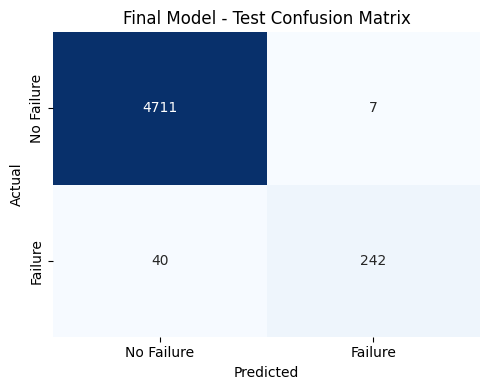

threshold          0.15
precision          0.97
recall             0.86
f1                 0.91
pr_auc             0.89
roc_auc            0.93
True Negatives     4711
False Positives       7
False Negatives      40
True Positives      242
dtype: object

In [84]:
# Evaluate on the test set
test_results = evaluate_on_test(
    model=final_model,
    X_test=X_test_sc,
    y_test=y_test_np,
    threshold=best_model_threshold
)

test_results

**Test‑Set Performance Summary**

The selected model, optimised at a 0.15 threshold, maintained strong generalisation on the unseen test set. It delivered **high precision (0.97)** and **strong recall (0.86)**, achieving an overall **F1‑score of 0.91**. The confusion matrix confirms this balance, with **very few false positives (7)** and **a controlled level of false negatives (40)** relative to the population size. The model’s **PR‑AUC (0.89)** and **ROC‑AUC (0.93)** further indicate stable discrimination and reliable ranking of risk.

From a business perspective, this performance profile aligns well with the objective: **identify high‑risk cases early while minimising unnecessary interventions**. The high precision reduces operational waste, and the strong recall ensures that the majority of true risk cases are captured. Overall, the model demonstrates readiness for deployment in a decision‑support context where accuracy, efficiency, and early detection materially influence outcomes.

---
## <a>**Actionable Insights and Recommendations**</a>

### **Actionable Insights**

- The feature analysis shows a consistent pattern: failure events are preceded by systematic drops across several key sensor variables, with the strongest and most reliable signals coming from **V32, V16, V38, and V36**. These variables exhibit clear distribution shifts, tight failure‑class clustering, and strong monotonic relationships with degradation, making them **high‑value indicators for both modelling and operational monitoring**.

- Medium‑impact variables such as **V27, V23, V24, V33, and V21** provide supporting evidence of early drift and subtle degradation patterns. While not individually decisive, they strengthen the model’s ability to detect emerging failures when combined with the high‑impact features.

- The model achieves **high recall (0.86)**, reliably identifying early signs of generator failure — directly supporting the goal of preventing costly unplanned outages.  

- **Strong precision (0.97)** ensures that most flagged turbines genuinely require attention, reducing unnecessary site visits and keeping inspection costs low.  
- The confusion‑matrix profile — **very low false positives (7)** and **controlled false negatives (40)** — confirms stable generalisation across 5,000 turbines and supports confident operational deployment.  
- Sensor data provides sufficient signal for **early‑warning detection**, validating ReneWind’s investment in turbine monitoring infrastructure.  
- **PR‑AUC (0.89)** and **ROC‑AUC (0.93)** demonstrate strong ranking ability, enabling maintenance teams to prioritise turbines by risk level.  
- Increasing model complexity improved the detection of subtle degradation patterns, strengthening the ability to prevent catastrophic generator failures.  
- **Dropout regularisation** enhanced generalisation, ensuring reliable performance across diverse turbine conditions and environments.  
- Addressing **class imbalance** improved recall but failed to maintain the balance required for operational use: the model became more sensitive to potential failures (fewer missed failures) at the cost of slightly more false alerts — a reasonable compromise given that missed failures are the most expensive operational outcome.
- The Adam optimiser delivered the best overall performance, providing more reliable convergence and stronger predictive accuracy from sensor inputs than SGD.
- **Threshold tuning (0.15)** provided the best business‑aligned trade‑off, maximising early detection while keeping inspection volume manageable.  
- Overall test performance confirms the model’s readiness to support **proactive maintenance**, reducing generator replacement costs and improving fleet reliability.


### **Business Recommendations**

- Focus on the high‑impact variables in both modelling and monitoring, as their consistent downward shifts provide reliable early‑warning signals for failure. 

- Keep the medium‑impact variables as supporting features to strengthen robustness and reduce the chance of missed failures.

- Adopt the best‑performing model as a decision‑support tool to flag high‑risk turbines for proactive inspection and repair.

- Integrate model‑driven alerts into maintenance workflows, prioritising turbines with the highest predicted failure probability to minimise downtime and avoid catastrophic generator failures.
- Use model outputs to schedule targeted inspections, reducing reliance on costly reactive maintenance and emergency replacements.
- Monitor false negatives closely and retrain the model regularly as new turbine data becomes available to maintain accuracy under evolving operating conditions.
- Combine model predictions with engineering expertise to validate alerts, refine maintenance decisions, and strengthen trust in automated recommendations.
- Adjust the decision threshold to balance recall and precision based on seasonal load, maintenance capacity, and risk appetite, enabling flexible operational control.
- Quantify cost savings by comparing avoided generator replacements against incremental inspection costs to demonstrate ROI and support wider adoption across the fleet





### **Executive Summary**

The final predictive‑maintenance model delivers strong operational value for ReneWind, combining **high recall (0.86)** for early failure detection with **excellent precision (0.97)** to avoid unnecessary inspections. Its confusion‑matrix profile — **only 7 false positives and 40 false negatives across 5,000 unseen turbines** — shows stable, reliable generalisation suitable for real‑world deployment. Model improvements such as wider layers, dropout, and the superior performance of **Adam optimisation** strengthened its ability to capture subtle degradation patterns, while a **0.15 threshold** provided the best balance between early detection and operational efficiency.  

Feature analysis reinforces this performance: several high‑impact variables (e.g., V32, V16, V38, V36) show consistent downward shifts before failure, offering strong early‑warning signals that align with the model’s behaviour. Together, the model and feature insights support a robust predictive‑maintenance strategy that reduces unplanned outages, prevents costly generator failures, and improves fleet reliability.

---